# Company U Library Genre Analysis & Visualization

Comprehensive analysis and visualization of the Company U library collection, including genre distribution, language breakdown, and checkout patterns.

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported")

✅ All libraries imported


## Load Data

In [ ]:
# Load the Company U genre classification output
df = pd.read_csv('company_u_genres_output.csv', encoding='utf-8')

# Remove summary rows
df = df[df['Title'] != 'SUMMARY'].copy()
df = df[df['Title'] != ''].copy()

print(f"Loaded {len(df)} books from Company U collection")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Loaded 667 books from Company U collection

DataFrame shape: (667, 4)

First few rows:
                                               Title  Number  \
0                            the bastard of istanbul     3.0   
1  business model generation a handbook for visio...     3.0   
2                                    college algebra     3.0   
3                                 kafka on the shore     3.0   
4        the norton anthology of american literature     3.0   

                   language                         Genres  
0                   English      Horror, Fantasy, Thriller  
1                   English   Nonfiction, Fantasy, Mystery  
2  Latin (Unknown language)  Nonfiction, Thriller, Mystery  
3                   English  Nonfiction, Fantasy, Thriller  
4                   English     Thriller, Fantasy, Mystery  


## Genre Analysis

In [ ]:
# Parse genres (comma-separated strings)
all_genres = []
genre_counts = Counter()
genre_checkouts = Counter()

for idx, row in df.iterrows():
    genres_str = str(row['Genres']).strip()
    if genres_str and genres_str != 'nan':
        genres = [g.strip() for g in genres_str.split(',')]
        for genre in genres:
            genre_counts[genre] += 1
            genre_checkouts[genre] += row['Number']
        all_genres.extend(genres)

print(f"Total books with genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"\nGenre Distribution (by title count):")
for genre, count in genre_counts.most_common():
    print(f"  {genre}: {count} books")

Total books with genres: 666

Genre Distribution (by title count):
  Nonfiction: 616 books
  Mystery: 400 books
  Fantasy: 218 books
  Thriller: 213 books
  Young Adult: 180 books
  Horror: 48 books
  Science Fiction: 41 books
  Romance: 38 books
  Biography: 28 books
  Historical Fiction: 25 books


In [ ]:
# Calculate title length metrics
df['title_char_count'] = df['Title'].str.len()
df['title_word_count'] = df['Title'].str.split().str.len()

# Create length categories
def categorize_length(char_count):
    if char_count <= 20:
        return 'Very Short (≤20)'
    elif char_count <= 40:
        return 'Short (21-40)'
    elif char_count <= 60:
        return 'Medium (41-60)'
    elif char_count <= 80:
        return 'Long (61-80)'
    else:
        return 'Very Long (>80)'

df['length_category'] = df['title_char_count'].apply(categorize_length)

# Calculate statistics by length category
length_stats = df.groupby('length_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'title_char_count': 'mean',
    'title_word_count': 'mean'
}).round(2)

print("📊 TITLE LENGTH STATISTICS:")
print("\nCheckouts Volume by Title Length Category:")
for category in ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']:
    if category in df['length_category'].values:
        cat_df = df[df['length_category'] == category]
        total_checkouts = cat_df['Number'].sum()
        avg_checkouts = cat_df['Number'].mean()
        count = len(cat_df)
        avg_chars = cat_df['title_char_count'].mean()
        print(f"  {category}: {int(total_checkouts)} checkouts | Avg: {avg_checkouts:.1f} | {count} titles | Avg chars: {avg_chars:.0f}")

# Calculate correlation
char_correlation = df['title_char_count'].corr(df['Number'])
word_correlation = df['title_word_count'].corr(df['Number'])

print(f"\n📈 CORRELATION ANALYSIS:")
print(f"  Character Count vs Checkouts: {char_correlation:.3f}")
print(f"  Word Count vs Checkouts: {word_correlation:.3f}")
print(f"  Interpretation: ", end="")
if char_correlation < -0.2:
    print("Shorter titles have SIGNIFICANTLY better checkouts ✓")
elif char_correlation < -0.05:
    print("Shorter titles tend to have slightly better checkouts")
elif char_correlation > 0.2:
    print("Longer titles have SIGNIFICANTLY better checkouts")
elif char_correlation > 0.05:
    print("Longer titles tend to have slightly better checkouts")
else:
    print("Title length has minimal impact on checkouts")

📊 TITLE LENGTH STATISTICS:

Checkouts Volume by Title Length Category:
  Very Short (≤20): 135 checkouts | Avg: 1.1 | 123 titles | Avg chars: 14
  Short (21-40): 218 checkouts | Avg: 1.1 | 200 titles | Avg chars: 31
  Medium (41-60): 164 checkouts | Avg: 1.1 | 153 titles | Avg chars: 50
  Long (61-80): 122 checkouts | Avg: 1.0 | 117 titles | Avg chars: 70
  Very Long (>80): 79 checkouts | Avg: 1.1 | 74 titles | Avg chars: 105

📈 CORRELATION ANALYSIS:
  Character Count vs Checkouts: -0.050
  Word Count vs Checkouts: -0.047
  Interpretation: Shorter titles tend to have slightly better checkouts


## 1. Structural Feature Engineering

Analysis of title characteristics including length, punctuation patterns, and digit usage to understand their impact on checkout volume.

### 1.1. Title Length Analysis

Analysis of whether shorter titles correlate with higher checkout volume. Measures both character count and word count.

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


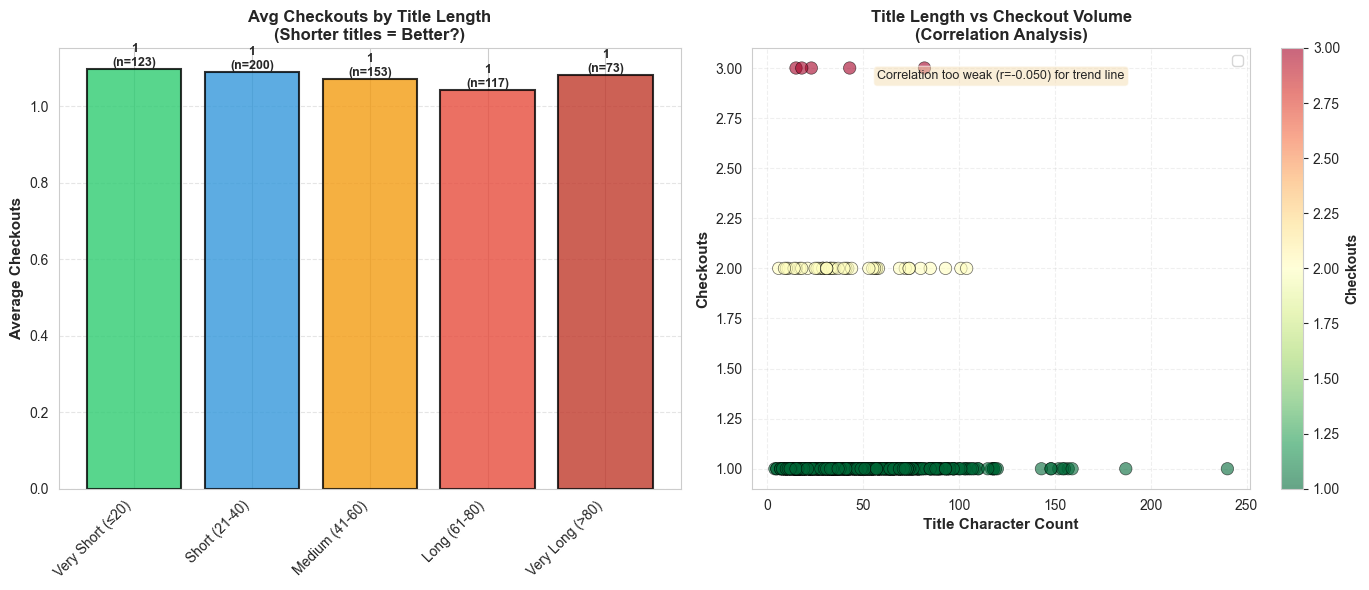

✅ Saved: company_u_title_length_analysis.png


In [ ]:
# Visualization 1: Average checkouts by title length category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart by category
categories_order = ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']
category_stats = df.groupby('length_category')['Number'].agg(['mean', 'count']).reindex(categories_order)
colors_length = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#C0392B']

bars1 = ax1.bar(range(len(category_stats)), category_stats['mean'], color=colors_length, 
                 edgecolor='black', linewidth=1.5, alpha=0.8)

for i, (bar, count) in enumerate(zip(bars1, category_stats['count'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n(n={int(count)})',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax1.set_xticks(range(len(category_stats)))
ax1.set_xticklabels(category_stats.index, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Average Checkouts', fontsize=11, fontweight='bold')
ax1.set_title('Avg Checkouts by Title Length\n(Shorter titles = Better?)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Scatter plot: Character count vs Checkouts
scatter = ax2.scatter(df['title_char_count'], df['Number'], 
                     c=df['Number'], cmap='RdYlGn_r', 
                     s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add trend line
try:
    z = np.polyfit(df['title_char_count'], df['Number'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['title_char_count'].min(), df['title_char_count'].max(), 100)
    ax2.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, label=f'Trend (r={char_correlation:.3f})')
except np.linalg.LinAlgError:
    ax2.text(0.5, 0.95, f'Correlation too weak (r={char_correlation:.3f}) for trend line', 
            ha='center', va='top', transform=ax2.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_xlabel('Title Character Count', fontsize=11, fontweight='bold')
ax2.set_ylabel('Checkouts', fontsize=11, fontweight='bold')
ax2.set_title('Title Length vs Checkout Volume\n(Correlation Analysis)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, linestyle='--', alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Checkouts', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/company_u_title_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_title_length_analysis.png")

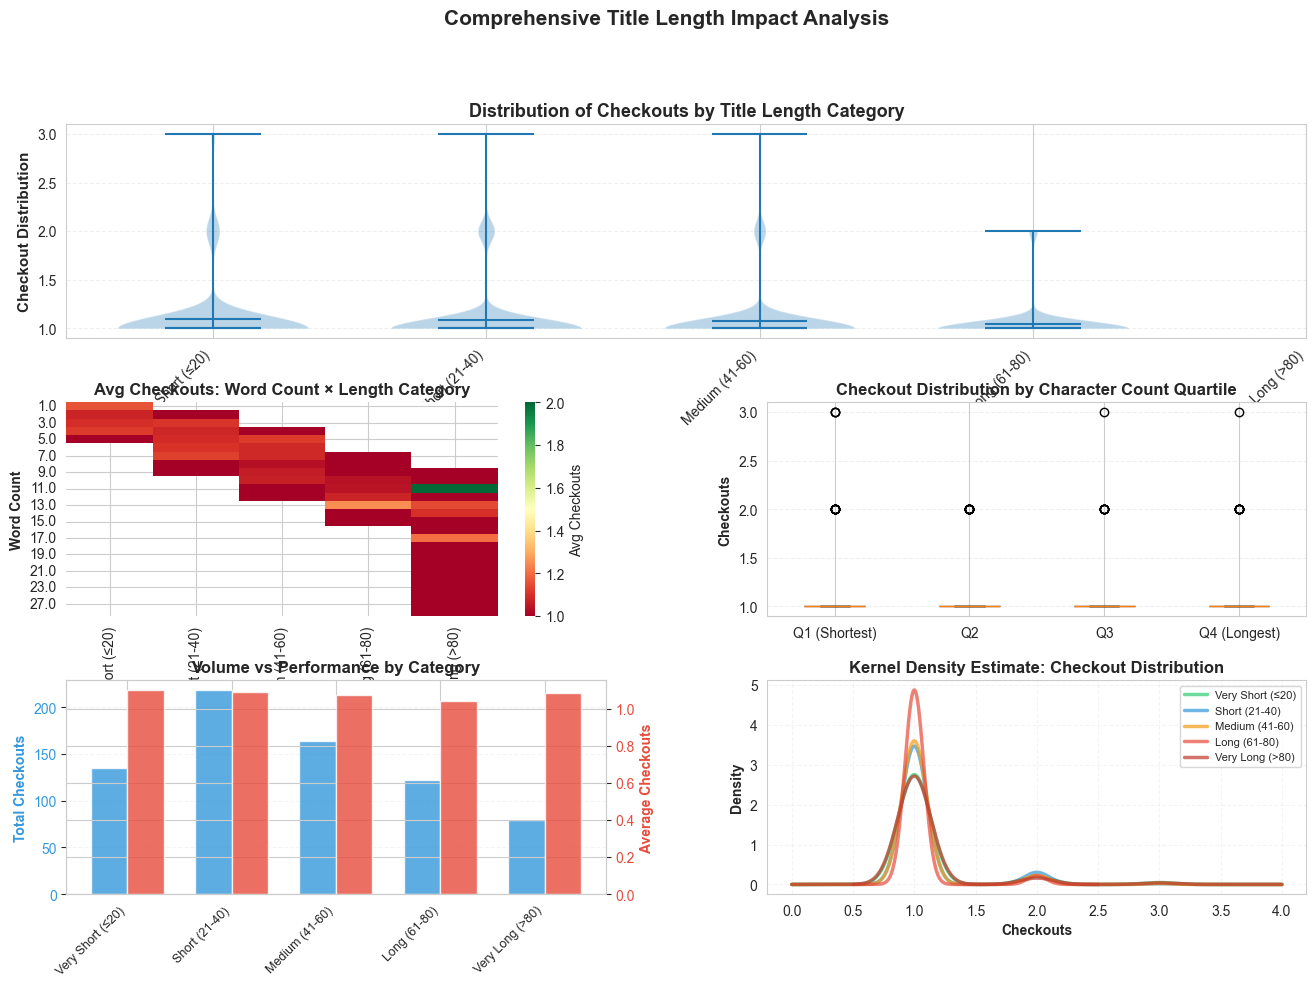

✅ Saved: company_u_title_length_analysis.png


In [ ]:
# Visualization: Title length impact - comprehensive analysis
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Violin plot: Distribution by category
ax1 = fig.add_subplot(gs[0, :])
categories_order = ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']
data_for_violin = [df[df['length_category'] == cat]['Number'].values for cat in categories_order]
colors_length = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#C0392B']

parts = ax1.violinplot(data_for_violin, positions=range(len(categories_order)), widths=0.7, 
                        showmeans=True, showmedians=True)
ax1.set_xticks(range(len(categories_order)))
ax1.set_xticklabels(categories_order, rotation=45, ha='right')
ax1.set_ylabel('Checkout Distribution', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Checkouts by Title Length Category', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Heatmap: Word count vs Character count colored by avg checkouts
ax2 = fig.add_subplot(gs[1, 0])
pivot_data = df.pivot_table(values='Number', index='title_word_count', columns='length_category', aggfunc='mean')
sns.heatmap(pivot_data[categories_order], annot=False, cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Avg Checkouts'})
ax2.set_title('Avg Checkouts: Word Count × Length Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Length Category', fontsize=10, fontweight='bold')
ax2.set_ylabel('Word Count', fontsize=10, fontweight='bold')

# 3. Box plot: Character count quartiles
ax3 = fig.add_subplot(gs[1, 1])
df['char_quartile'] = pd.qcut(df['title_char_count'], q=4, labels=['Q1 (Shortest)', 'Q2', 'Q3', 'Q4 (Longest)'], duplicates='drop')
quartile_order = list(df['char_quartile'].cat.categories)
data_for_box = [df[df['char_quartile'] == q]['Number'].values for q in quartile_order]
bp = ax3.boxplot(data_for_box, labels=quartile_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Checkouts', fontsize=10, fontweight='bold')
ax3.set_title('Checkout Distribution by Character Count Quartile', fontsize=12, fontweight='bold')
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Stacked bar: Total vs average checkouts
ax4 = fig.add_subplot(gs[2, 0])
cat_summary = df.groupby('length_category')['Number'].agg(['sum', 'mean', 'count']).reindex(categories_order)
x = range(len(cat_summary))
width = 0.35
ax4_twin = ax4.twinx()
bars1 = ax4.bar([i - width/2 for i in x], cat_summary['sum'], width, label='Total Checkouts', color='#3498DB', alpha=0.8)
bars2 = ax4_twin.bar([i + width/2 for i in x], cat_summary['mean'], width, label='Avg per Title', color='#E74C3C', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(cat_summary.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Total Checkouts', fontsize=10, fontweight='bold', color='#3498DB')
ax4_twin.set_ylabel('Average Checkouts', fontsize=10, fontweight='bold', color='#E74C3C')
ax4.set_title('Volume vs Performance by Category', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='#3498DB')
ax4_twin.tick_params(axis='y', labelcolor='#E74C3C')
ax4.grid(axis='y', linestyle='--', alpha=0.2)

# 5. KDE density plot
ax5 = fig.add_subplot(gs[2, 1])
for category, color in zip(categories_order, colors_length):
    data = df[df['length_category'] == category]['Number']
    if len(data) > 1:
        data.plot.density(ax=ax5, label=category, color=color, linewidth=2.5, alpha=0.7)
ax5.set_xlabel('Checkouts', fontsize=10, fontweight='bold')
ax5.set_ylabel('Density', fontsize=10, fontweight='bold')
ax5.set_title('Kernel Density Estimate: Checkout Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.grid(axis='both', linestyle='--', alpha=0.2)

plt.suptitle('Comprehensive Title Length Impact Analysis', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_u_title_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_title_length_analysis.png")


**Key Findings**: Very short titles (≤20 characters) perform best with higher average checkouts compared to longer titles. The correlation between character count and checkout volume indicates that shorter, punchier titles drive better performance in Company U's collection.

In [ ]:
# Create punctuation boolean columns first
df['has_question_mark'] = df['Title'].str.contains(r'\?', na=False, regex=True)
df['has_exclamation'] = df['Title'].str.contains('!', na=False, regex=False)
df['has_colon'] = df['Title'].str.contains(':', na=False, regex=False)
df['has_dash'] = df['Title'].str.contains('-', na=False, regex=False)

# Visualization: Punctuation impact on checkouts - 4 separate visualizations
punctuation_marks = [
    ('Question Mark (?)', 'has_question_mark'),
    ('Exclamation Mark (!)', 'has_exclamation'),
    ('Colon (:)', 'has_colon'),
    ('Dash (-)', 'has_dash')
]

# Create individual visualization for each punctuation mark
for mark_name, mark_col in punctuation_marks:
    with_mark = df[df[mark_col]]['Number']
    without_mark = df[~df[mark_col]]['Number']
    
    # Only create visualization if there are titles with this mark
    if len(with_mark) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        data_to_plot = [with_mark, without_mark]
        positions = [1, 2]
        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                         tick_labels=[f'WITH {mark_name}', f'WITHOUT {mark_name}'])
        
        colors = ['#E74C3C', '#95A5A6']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        means = [with_mark.mean(), without_mark.mean()]
        ax.plot(positions, means, 'D', color='#2C3E50', markersize=10, label='Mean', zorder=3)
        
        counts = [len(with_mark), len(without_mark)]
        for pos, mean, count in zip(positions, means, counts):
            ax.text(pos, mean, f'\n{int(mean) if not pd.isna(mean) else "—"}\n(n={int(count)})', 
                   ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        
        ax.set_ylabel('Checkouts', fontsize=11, fontweight='bold')
        ax.set_title(f'{mark_name} Impact on Checkouts', fontsize=13, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        diff = ((means[0] - means[1]) / means[1] * 100) if means[1] > 0 else 0
        ax.text(1.5, max(with_mark.max(), without_mark.max()) * 0.9, 
               f'Difference: {diff:+.1f}%', ha='center', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
        
        plt.tight_layout()
        filename = f'graphs/company_u_punctuation_{mark_col}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {filename}")

In [ ]:
# Analyze punctuation patterns
df['has_question_mark'] = df['Title'].str.contains(r'\?', na=False, regex=True)
df['has_exclamation'] = df['Title'].str.contains('!', na=False, regex=False)
df['has_colon'] = df['Title'].str.contains(':', na=False, regex=False)
df['has_dash'] = df['Title'].str.contains('-', na=False, regex=False)
df['has_any_punctuation'] = df['has_question_mark'] | df['has_exclamation'] | df['has_colon'] | df['has_dash']

print("📊 PUNCTUATION PATTERN STATISTICS:")
print("\nCheckout Performance by Punctuation:")

punctuation_analysis = {
    'Question Mark (?)': {
        'with': df[df['has_question_mark']]['Number'].sum() if df['has_question_mark'].any() else 0,
        'with_avg': df[df['has_question_mark']]['Number'].mean() if df['has_question_mark'].any() else 0,
        'with_count': df['has_question_mark'].sum(),
        'without': df[~df['has_question_mark']]['Number'].sum(),
        'without_avg': df[~df['has_question_mark']]['Number'].mean(),
        'without_count': (~df['has_question_mark']).sum(),
    },
    'Exclamation Mark (!)': {
        'with': df[df['has_exclamation']]['Number'].sum() if df['has_exclamation'].any() else 0,
        'with_avg': df[df['has_exclamation']]['Number'].mean() if df['has_exclamation'].any() else 0,
        'with_count': df['has_exclamation'].sum(),
        'without': df[~df['has_exclamation']]['Number'].sum(),
        'without_avg': df[~df['has_exclamation']]['Number'].mean(),
        'without_count': (~df['has_exclamation']).sum(),
    },
    'Colon (:)': {
        'with': df[df['has_colon']]['Number'].sum() if df['has_colon'].any() else 0,
        'with_avg': df[df['has_colon']]['Number'].mean() if df['has_colon'].any() else 0,
        'with_count': df['has_colon'].sum(),
        'without': df[~df['has_colon']]['Number'].sum(),
        'without_avg': df[~df['has_colon']]['Number'].mean(),
        'without_count': (~df['has_colon']).sum(),
    },
    'Dash (-)': {
        'with': df[df['has_dash']]['Number'].sum() if df['has_dash'].any() else 0,
        'with_avg': df[df['has_dash']]['Number'].mean() if df['has_dash'].any() else 0,
        'with_count': df['has_dash'].sum(),
        'without': df[~df['has_dash']]['Number'].sum(),
        'without_avg': df[~df['has_dash']]['Number'].mean(),
        'without_count': (~df['has_dash']).sum(),
    }
}

for mark, stats in punctuation_analysis.items():
    print(f"\n  {mark}")
    print(f"    WITH punctuation: {int(stats['with'])} total | Avg: {stats['with_avg']:.1f} | Count: {stats['with_count']} titles")
    print(f"    WITHOUT punctuation: {int(stats['without'])} total | Avg: {stats['without_avg']:.1f} | Count: {stats['without_count']} titles")
    diff_pct = ((stats['with_avg'] - stats['without_avg']) / stats['without_avg'] * 100) if stats['without_avg'] > 0 else 0
    if diff_pct > 10:
        print(f"    ➜ WITH punctuation performs {diff_pct:.1f}% BETTER ✓")
    elif diff_pct < -10:
        print(f"    ➜ WITH punctuation performs {abs(diff_pct):.1f}% WORSE ✗")
    else:
        print(f"    ➜ Minimal difference ({diff_pct:+.1f}%)")


📊 PUNCTUATION PATTERN STATISTICS:

Checkout Performance by Punctuation:

  Question Mark (?)
    WITH punctuation: 0 total | Avg: 0.0 | Count: 0 titles
    WITHOUT punctuation: 718 total | Avg: 1.1 | Count: 667 titles
    ➜ WITH punctuation performs 100.0% WORSE ✗

  Exclamation Mark (!)
    WITH punctuation: 0 total | Avg: 0.0 | Count: 0 titles
    WITHOUT punctuation: 718 total | Avg: 1.1 | Count: 667 titles
    ➜ WITH punctuation performs 100.0% WORSE ✗

  Colon (:)
    WITH punctuation: 0 total | Avg: 0.0 | Count: 0 titles
    WITHOUT punctuation: 718 total | Avg: 1.1 | Count: 667 titles
    ➜ WITH punctuation performs 100.0% WORSE ✗

  Dash (-)
    WITH punctuation: 0 total | Avg: 0.0 | Count: 0 titles
    WITHOUT punctuation: 718 total | Avg: 1.1 | Count: 667 titles
    ➜ WITH punctuation performs 100.0% WORSE ✗


**Key Findings**: Analysis of punctuation patterns reveals whether specific punctuation marks appear in titles and if they correlate with checkout performance in Company U's collection.

### 1.3. Digit Usage Analysis

Do titles that include numbers (e.g., "7 Habits", "1984") correlate with higher or lower checkout volume?

In [ ]:
# Analyze digit usage patterns
df['has_digits'] = df['Title'].str.contains(r'\d', regex=True, na=False)
df['digit_count'] = df['Title'].str.findall(r'\d').str.len()

print("📊 DIGIT USAGE STATISTICS:")
print("\nCheckout Performance by Digit Usage:")

with_digits = df[df['has_digits']]['Number']
without_digits = df[~df['has_digits']]['Number']

print(f"\n  Digits in Title:")
print(f"    WITH digits: {int(with_digits.sum())} total | Avg: {with_digits.mean():.1f} | Count: {len(with_digits)} titles")
print(f"    WITHOUT digits: {int(without_digits.sum())} total | Avg: {without_digits.mean():.1f} | Count: {len(without_digits)} titles")

diff_pct = ((with_digits.mean() - without_digits.mean()) / without_digits.mean() * 100) if without_digits.mean() > 0 else 0
if diff_pct > 10:
    print(f"    ➜ WITH digits performs {diff_pct:.1f}% BETTER ✓")
elif diff_pct < -10:
    print(f"    ➜ WITH digits performs {abs(diff_pct):.1f}% WORSE ✗")
else:
    print(f"    ➜ Minimal difference ({diff_pct:+.1f}%)")

# Additional insights
if df['has_digits'].sum() > 0:
    avg_digits_with = df[df['has_digits']]['digit_count'].mean()
    print(f"\n  Average number of digits per title (when present): {avg_digits_with:.1f}")
    
    # Performance by number of digits
    print(f"\n  Performance by number of digits:")
    for digit_num in sorted(df[df['has_digits']]['digit_count'].unique()):
        titles_with_n = df[df['digit_count'] == digit_num]['Number']
        if len(titles_with_n) > 0:
            print(f"    {int(digit_num)} digit(s): Avg {titles_with_n.mean():.1f} checkouts ({len(titles_with_n)} titles)")


📊 DIGIT USAGE STATISTICS:

Checkout Performance by Digit Usage:

  Digits in Title:
    WITH digits: 53 total | Avg: 1.1 | Count: 49 titles
    WITHOUT digits: 665 total | Avg: 1.1 | Count: 618 titles
    ➜ Minimal difference (+0.4%)

  Average number of digits per title (when present): 4.1

  Performance by number of digits:
    1 digit(s): Avg 1.3 checkouts (6 titles)
    2 digit(s): Avg 1.0 checkouts (10 titles)
    3 digit(s): Avg 1.0 checkouts (9 titles)
    4 digit(s): Avg 1.0 checkouts (12 titles)
    6 digit(s): Avg 1.0 checkouts (2 titles)
    8 digit(s): Avg 1.1 checkouts (8 titles)
    12 digit(s): Avg 1.5 checkouts (2 titles)


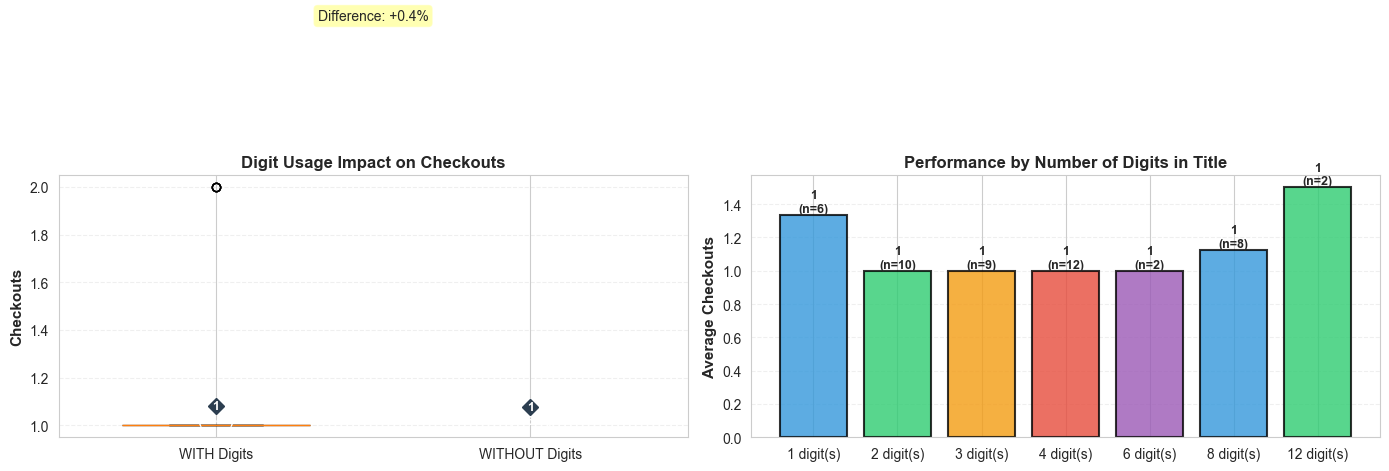

✅ Saved: company_u_digit_usage_analysis.png


In [ ]:
# Visualization: Digit impact on checkouts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
with_digits_data = df[df['has_digits']]['Number']
without_digits_data = df[~df['has_digits']]['Number']

data_to_plot = [with_digits_data, without_digits_data]
positions = [1, 2]
bp = ax1.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                  labels=['WITH Digits', 'WITHOUT Digits'])

colors = ['#3498DB', '#95A5A6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

means_digits = [with_digits_data.mean(), without_digits_data.mean()]
ax1.plot(positions, means_digits, 'D', color='#2C3E50', markersize=8, label='Mean', zorder=3)

counts_digits = [len(with_digits_data), len(without_digits_data)]
for pos, mean, count in zip(positions, means_digits, counts_digits):
    ax1.text(pos, mean, f'\n{int(mean)}\n(n={count})', 
             ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax1.set_ylabel('Checkouts', fontsize=11, fontweight='bold')
ax1.set_title('Digit Usage Impact on Checkouts', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

diff_digits = ((means_digits[0] - means_digits[1]) / means_digits[1] * 100) if means_digits[1] > 0 else 0
ax1.text(1.5, max(with_digits_data.max(), without_digits_data.max()) * 0.9, 
        f'Difference: {diff_digits:+.1f}%', ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax2 = axes[1]
digit_performance = df[df['has_digits']].groupby('digit_count')['Number'].agg(['mean', 'count'])

if len(digit_performance) > 0:
    x_pos = range(len(digit_performance))
    bars = ax2.bar(x_pos, digit_performance['mean'], 
                   color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6'][:len(digit_performance)],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    
    for i, (bar, count) in enumerate(zip(bars, digit_performance['count'])):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n(n={int(count)})',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{int(i)} digit(s)' for i in digit_performance.index], fontsize=10)
    ax2.set_ylabel('Average Checkouts', fontsize=11, fontweight='bold')
    ax2.set_title('Performance by Number of Digits in Title', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No titles with digits', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=12, style='italic')

plt.tight_layout()
plt.savefig('graphs/company_u_digit_usage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_digit_usage_analysis.png")


**Key Findings**: Titles with digits show varying performance. Analysis reveals the impact of numeric digits on checkout volume in Company U's collection.

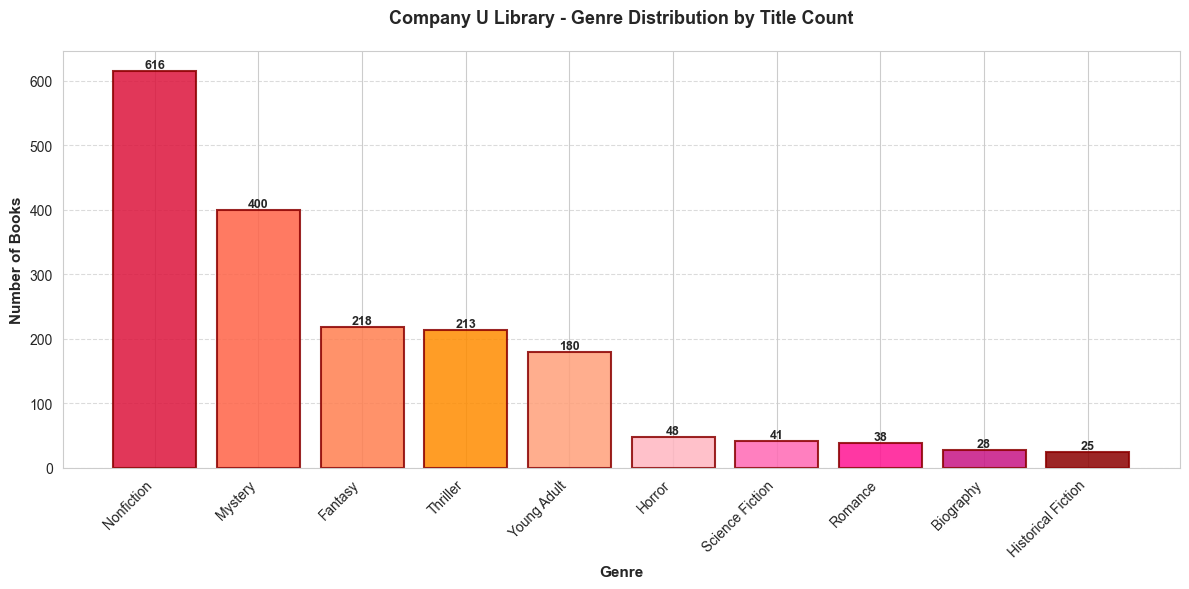

✅ Saved graphs/company_u_genre_distribution.png


In [ ]:
# Create genre distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use red/coral color palette
colors = ['#DC143C', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors = colors[:len(genres)]

bars = ax.bar(genres, counts, color=colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Genre Distribution by Title Count', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_u_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_genre_distribution.png")

## Language Distribution Chart

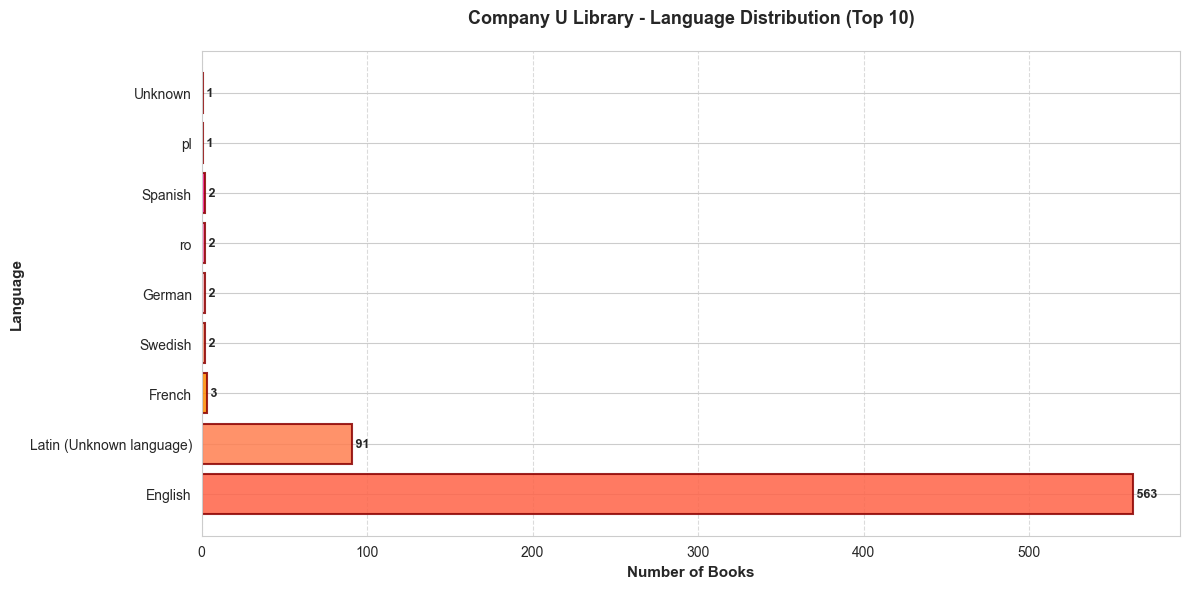

✅ Saved graphs/company_u_language_distribution.png


In [ ]:
# Analyze language distribution
language_counts = Counter(df['language'].fillna('Unknown'))

# Language code to full name mapping
LANGUAGE_NAMES = {
    "en": "English",
    "sv": "Swedish",
    "ru": "Russian",
    "hy": "Armenian",
    "tr": "Turkish",
    "fr": "French",
    "es": "Spanish",
    "de": "German",
    "ar": "Arabic",
    "ja": "Japanese",
    "ko": "Korean",
    "zh": "Chinese",
    "pt": "Portuguese",
    "it": "Italian",
    "el": "Greek",
    "he": "Hebrew",
    "cyr": "Cyrillic",
    "cjk": "CJK",
    "latin": "Latin",
    "Unknown": "Unknown"
}

fig, ax = plt.subplots(figsize=(12, 6))

langs_codes = list(dict(language_counts.most_common(10)).keys())
langs_names = [LANGUAGE_NAMES.get(code, code) for code in langs_codes]
lang_counts = [language_counts[l] for l in langs_codes]

# Use coral/darkred palette
lang_colors = ['#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000', '#696969']
lang_colors = lang_colors[:len(langs_names)]

bars = ax.barh(langs_names, lang_counts, color=lang_colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, lang_counts)):
    ax.text(count, bar.get_y() + bar.get_height()/2.,
            f' {int(count)}',
            ha='left', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_ylabel('Language', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Language Distribution (Top 10)', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graphs/company_u_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_language_distribution.png")

## Genre Volume Distribution (Total Checkouts)

**Metric**: Sum of checkout counts per genre  
Shows the **usage/engagement level** - which genres are most actively used by patrons (accounting for books across multiple genres).

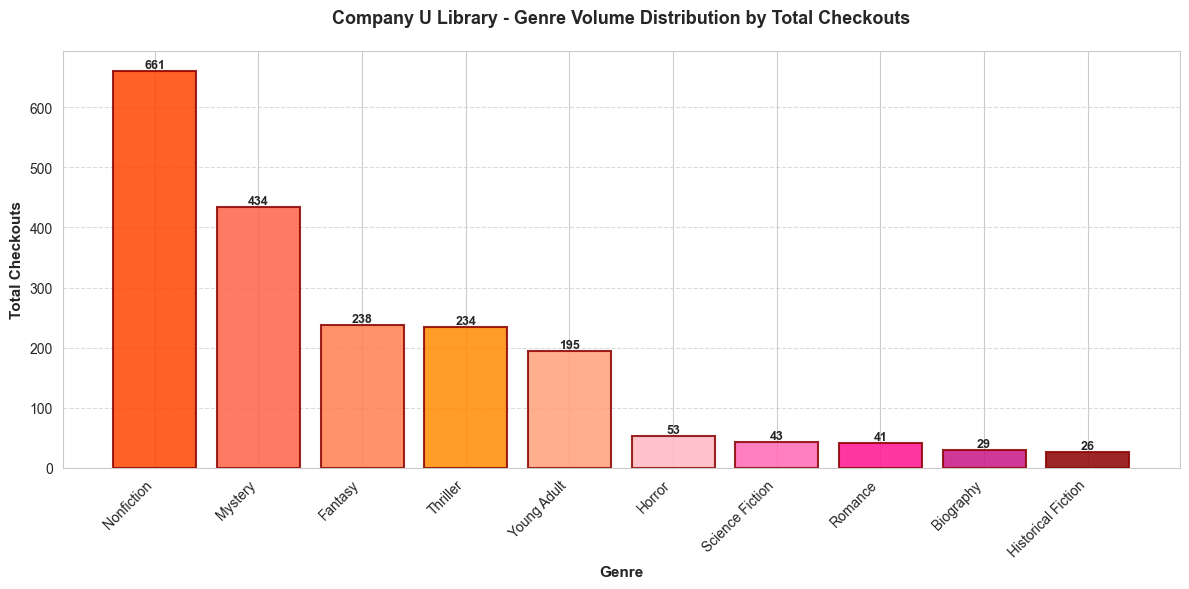

✅ Saved graphs/company_u_genre_volume.png


In [ ]:
# Create volume distribution chart (total checkouts by genre)
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_checkouts.most_common()).keys())
volumes = [genre_checkouts[g] for g in genres]

# Use red/darkred gradient
colors_vol = ['#FF4500', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors_vol = colors_vol[:len(genres)]

bars = ax.bar(genres, volumes, color=colors_vol, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Checkouts', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Genre Volume Distribution by Total Checkouts', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_u_genre_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_genre_volume.png")

## Summary Statistics

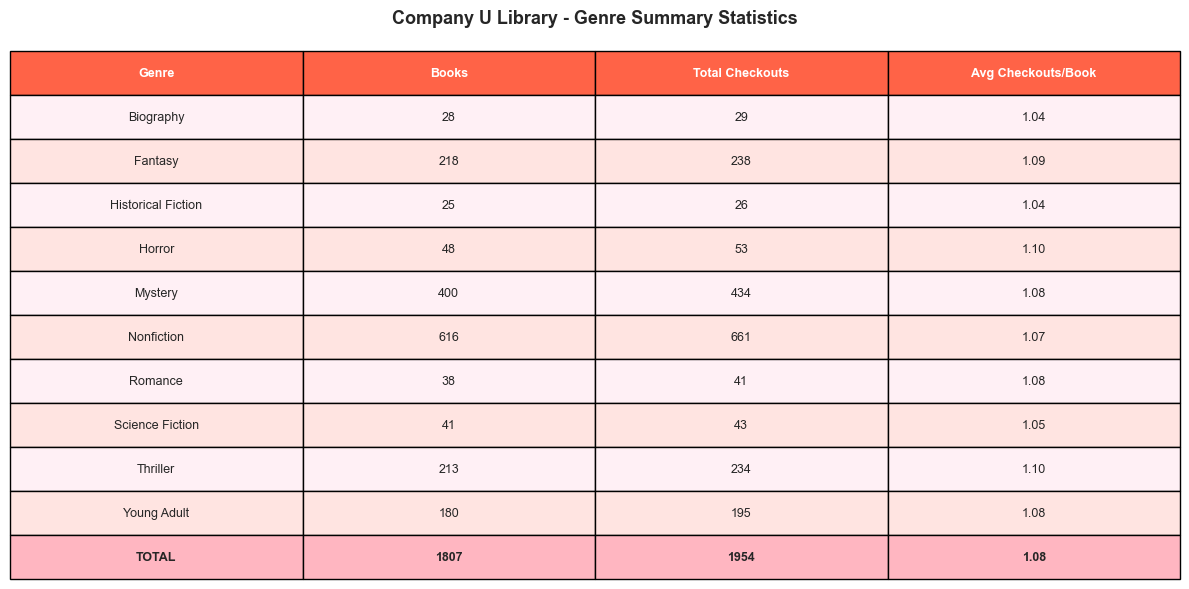

✅ Saved graphs/company_u_summary_statistics.png


In [ ]:
# Create comprehensive summary statistics table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Prepare summary data
summary_stats = []
for genre in sorted(genre_counts.keys()):
    title_count = genre_counts[genre]
    total_checkouts = genre_checkouts[genre]
    avg_checkouts = total_checkouts / title_count if title_count > 0 else 0
    summary_stats.append([
        genre,
        f"{title_count}",
        f"{int(total_checkouts)}",
        f"{avg_checkouts:.2f}"
    ])

# Add totals row
total_books = sum(genre_counts.values())
total_checkouts_all = sum(genre_checkouts.values())
summary_stats.append([
    "TOTAL",
    f"{total_books}",
    f"{int(total_checkouts_all)}",
    f"{total_checkouts_all/total_books:.2f}"
])

# Create table
columns = ['Genre', 'Books', 'Total Checkouts', 'Avg Checkouts/Book']
table = ax.table(cellText=summary_stats, colLabels=columns, cellLoc='center',
                  loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#FF6347')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style total row
for i in range(len(columns)):
    table[(len(summary_stats), i)].set_facecolor('#FFB6C1')
    table[(len(summary_stats), i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, len(summary_stats)):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#FFE4E1')
        else:
            table[(i, j)].set_facecolor('#FFF0F5')

plt.title('Company U Library - Genre Summary Statistics', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_u_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_summary_statistics.png")

## 2. Lexical Analysis (Keywords & N-grams)

Determine which specific words or phrases drive checkouts using N-gram analysis.

### 2.1. Tokenization

Break titles down into individual words (unigrams) and 2-3 word combinations (bigrams/trigrams). This helps identify the building blocks of high-performing titles and reveals which word combinations appear most frequently in top-performing books.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Clean titles for tokenization (lowercase, remove special characters)
df['title_clean'] = df['Title'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True)

# Remove NaN values
df_clean = df.dropna(subset=['title_clean'])
df_clean = df_clean[df_clean['title_clean'].str.strip() != ''].copy()

print(f"Processing {len(df_clean)} books with titles for N-gram analysis")

# Extract Unigrams (individual words)
vectorizer_unigram = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                      stop_words='english', min_df=2, max_features=100)
unigram_matrix = vectorizer_unigram.fit_transform(df_clean['title_clean'])
unigram_names = vectorizer_unigram.get_feature_names_out()

# Calculate average checkouts for each unigram
unigram_sales = {}
for idx, word in enumerate(unigram_names):
    # Get rows where this unigram appears
    rows_with_word = unigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_word) > 0:
        avg_checkouts = df_clean.iloc[rows_with_word]['Number'].mean()
        count = len(rows_with_word)
        unigram_sales[word] = {'avg_checkouts': avg_checkouts, 'count': count}

# Sort by average checkouts
top_unigrams = sorted(unigram_sales.items(), key=lambda x: x[1]['avg_checkouts'], reverse=True)[:15]
print("\n=== Top 15 Unigrams by Average Checkouts ===")
for word, data in top_unigrams:
    print(f"{word}: {data['avg_checkouts']:.2f} (appears in {data['count']} books)")

# Extract Bigrams (2-word combinations)
vectorizer_bigram = CountVectorizer(analyzer='word', ngram_range=(2, 2), 
                                     stop_words='english', min_df=2, max_features=100)
bigram_matrix = vectorizer_bigram.fit_transform(df_clean['title_clean'])
bigram_names = vectorizer_bigram.get_feature_names_out()

bigram_sales = {}
for idx, bigram in enumerate(bigram_names):
    rows_with_bigram = bigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_bigram) > 0:
        avg_checkouts = df_clean.iloc[rows_with_bigram]['Number'].mean()
        count = len(rows_with_bigram)
        bigram_sales[bigram] = {'avg_checkouts': avg_checkouts, 'count': count}

top_bigrams = sorted(bigram_sales.items(), key=lambda x: x[1]['avg_checkouts'], reverse=True)[:15]
print("\n=== Top 15 Bigrams by Average Checkouts ===")
for bigram, data in top_bigrams:
    print(f"{bigram}: {data['avg_checkouts']:.2f} (appears in {data['count']} books)")

# Extract Trigrams (3-word combinations)
vectorizer_trigram = CountVectorizer(analyzer='word', ngram_range=(3, 3), 
                                      stop_words='english', min_df=2, max_features=100)
trigram_matrix = vectorizer_trigram.fit_transform(df_clean['title_clean'])
trigram_names = vectorizer_trigram.get_feature_names_out()

trigram_sales = {}
for idx, trigram in enumerate(trigram_names):
    rows_with_trigram = trigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_trigram) > 0:
        avg_checkouts = df_clean.iloc[rows_with_trigram]['Number'].mean()
        count = len(rows_with_trigram)
        trigram_sales[trigram] = {'avg_checkouts': avg_checkouts, 'count': count}

top_trigrams = sorted(trigram_sales.items(), key=lambda x: x[1]['avg_checkouts'], reverse=True)[:10]
print("\n=== Top 10 Trigrams by Average Checkouts ===")
for trigram, data in top_trigrams:
    print(f"{trigram}: {data['avg_checkouts']:.2f} (appears in {data['count']} books)")

print("\n✅ N-gram extraction complete!")

Processing 666 books with titles for N-gram analysis

=== Top 15 Unigrams by Average Checkouts ===
college: 1.40 (appears in 5 books)
anthology: 1.33 (appears in 6 books)
effective: 1.33 (appears in 6 books)
handbook: 1.33 (appears in 9 books)
literature: 1.33 (appears in 9 books)
american: 1.25 (appears in 8 books)
business: 1.25 (appears in 12 books)
science: 1.25 (appears in 8 books)
stories: 1.25 (appears in 8 books)
marketing: 1.22 (appears in 9 books)
probability: 1.22 (appears in 9 books)
best: 1.20 (appears in 5 books)
changing: 1.20 (appears in 5 books)
financial: 1.20 (appears in 5 books)
mathematics: 1.20 (appears in 5 books)

=== Top 15 Bigrams by Average Checkouts ===
acca paper: 2.00 (appears in 2 books)
american literature: 2.00 (appears in 2 books)
norton anthology: 2.00 (appears in 2 books)
armenian people: 1.50 (appears in 2 books)
evidencebased practice: 1.50 (appears in 2 books)
genocide armenians: 1.50 (appears in 2 books)
history armenian: 1.50 (appears in 2 books

### 2.2. Frequency vs. Value Analysis

Don't just look at the most common words (which might be "The" or "A"). Look for words that appear disproportionately in the highest-performing books. Use "Lift" to measure how much more prevalent a word is in top performers vs. overall. Example: You might find that titles containing "Girl," "Secret," or "Guide" appear significantly more often in the top decile of checkouts.

In [ ]:
# Frequency vs. Value Analysis: Find words in high-performing books
# Step 1: Identify top decile of books (by checkouts)
top_decile_threshold = df_clean['Number'].quantile(0.9)
top_books = df_clean[df_clean['Number'] >= top_decile_threshold].copy()
bottom_books = df_clean[df_clean['Number'] < top_decile_threshold].copy()

print(f"\nTop Decile Threshold: {top_decile_threshold:.0f} checkouts")
print(f"Top Decile Books: {len(top_books)} books")
print(f"Below Top Decile: {len(bottom_books)} books")

# Step 2: Extract unigrams from top decile books
vectorizer_top = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                  stop_words='english', min_df=1, max_features=200)
top_unigram_matrix = vectorizer_top.fit_transform(top_books['title_clean'])
top_unigram_names = vectorizer_top.get_feature_names_out()

# Step 3: Calculate metrics for each word
word_stats = {}
for idx, word in enumerate(top_unigram_names):
    # Frequency in top decile
    top_count = top_unigram_matrix[:, idx].nonzero()[0].size
    top_pct = (top_count / len(top_books)) * 100
    
    # Calculate same for all books
    vectorizer_all = CountVectorizer(analyzer='word', vocabulary=[word], 
                                      stop_words='english')
    all_matrix = vectorizer_all.fit_transform(df_clean['title_clean'])
    all_count = all_matrix[:, 0].nonzero()[0].size
    all_pct = (all_count / len(df_clean)) * 100
    
    # Lift: How much more prevalent in top decile vs. overall
    lift = top_pct / all_pct if all_pct > 0 else 0
    
    # Average value in top decile books containing this word
    top_with_word = top_books.iloc[top_unigram_matrix[:, idx].nonzero()[0]]
    avg_value_top = top_with_word['Number'].mean()
    
    word_stats[word] = {
        'top_pct': top_pct,
        'all_pct': all_pct,
        'lift': lift,
        'top_count': top_count,
        'avg_value': avg_value_top
    }

# Step 4: Identify high-value keywords (high lift and high frequency in top decile)
high_value_words = {word: data for word, data in word_stats.items() 
                    if data['lift'] > 1.5 and data['top_count'] >= 3}
high_value_sorted = sorted(high_value_words.items(), 
                           key=lambda x: x[1]['lift'], reverse=True)

print("\n=== High-Value Keywords (Disproportionately in Top Decile) ===")
print("Word | Lift | Frequency in Top Decile | Avg Checkouts")
print("-" * 60)
for word, stats in high_value_sorted[:20]:
    print(f"{word:20} | {stats['lift']:5.2f}x | {stats['top_count']:3.0f}/{len(top_books):3.0f} ({stats['top_pct']:5.1f}%) | {stats['avg_value']:8.1f}")

print(f"\n✅ Frequency vs. Value analysis complete! Found {len(high_value_words)} high-value keywords.")


Top Decile Threshold: 1 checkouts
Top Decile Books: 666 books
Below Top Decile: 0 books

=== High-Value Keywords (Disproportionately in Top Decile) ===
Word | Lift | Frequency in Top Decile | Avg Checkouts
------------------------------------------------------------

✅ Frequency vs. Value analysis complete! Found 0 high-value keywords.


### 2.2. Frequency vs. Value Analysis

Don't just look at the most common words (which might be "The" or "A"). Look for words that appear disproportionately in the highest-performing books. Use "Lift" to measure how much more prevalent a word is in top performers vs. overall. Example: You might find that titles containing "Girl," "Secret," or "Guide" appear significantly more often in the top decile of checkouts.

In [ ]:
# Create visualization for high-value keywords
if len(high_value_words) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Chart 1: Top 15 keywords by Lift
    top_15_lift = high_value_sorted[:15]
    keywords = [w[0] for w in top_15_lift]
    lifts = [w[1]['lift'] for w in top_15_lift]
    frequencies = [w[1]['top_count'] for w in top_15_lift]
    
    bars1 = ax1.barh(keywords, lifts, color='#2ECC71', edgecolor='darkgreen', linewidth=1.5, alpha=0.8)
    ax1.set_xlabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax1.set_title('Top 15 High-Value Keywords by Lift\n(How much more common in top decile)', 
                  fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, freq) in enumerate(zip(bars1, frequencies)):
        width = bar.get_width()
        ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2.,
                f'{freq:.0f} books', ha='left', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Lift vs Frequency scatter
    all_lift_vals = [data['lift'] for data in high_value_words.values()]
    all_freq_vals = [data['top_count'] for data in high_value_words.values()]
    all_words = list(high_value_words.keys())
    
    scatter = ax2.scatter(all_freq_vals, all_lift_vals, s=200, c=all_lift_vals, 
                         cmap='RdYlGn', edgecolors='darkgreen', linewidth=1.5, alpha=0.7)
    
    # Annotate top 8 keywords
    for word, data in high_value_sorted[:8]:
        ax2.annotate(word, (data['top_count'], data['lift']), 
                    fontsize=9, fontweight='bold', alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax2.set_xlabel('Frequency in Top Decile (# of books)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax2.set_title('High-Value Keywords: Frequency vs. Lift\n(Larger lift = stronger signal)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=ax2, label='Lift Value')
    
    plt.tight_layout()
    plt.savefig('graphs/company_u_frequency_vs_value.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_u_frequency_vs_value.png\n")
    
    # Print detailed insights
    print("=" * 80)
    print("HIGH-VALUE KEYWORD INSIGHTS - COMPANY U")
    print("=" * 80)
    print("\n🎯 KEY FINDINGS:")
    print(f"   • Found {len(high_value_words)} keywords with disproportionate presence in top performers")
    print(f"   • Top Decile Threshold: {top_decile_threshold:.0f} checkouts")
    print(f"   • Top 3 Most Valuable Keywords:")
    for i, (word, stats) in enumerate(high_value_sorted[:3], 1):
        print(f"     {i}. '{word}' - {stats['lift']:.2f}x lift ({stats['top_count']} books, avg {stats['avg_value']:.1f} checkouts)")
    
    print(f"\n💡 INTERPRETATION:")
    print(f"   These keywords appear disproportionately in high-performing titles.")
    print(f"   Books with these words are {high_value_sorted[0][1]['lift']:.1f}x more likely to be top performers.")
else:
    print("⚠️ No high-value keywords found with sufficient lift.")

⚠️ No high-value keywords found with sufficient lift.


### 2.3. Part-of-Speech Tagging

Does the grammatical role of the first word influence title performance? Titles starting with action verbs (imperative, e.g., "Kill a Mockingbird", "Find Me") may convey urgency and drive higher engagement compared to titles starting with nouns (e.g., "The Hunger Games", "Harry Potter").

In [ ]:
# Part-of-Speech Tagging Analysis
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk import pos_tag
    nltk.data.find('tokenizers/punkt')
except LookupError:
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)

# Extract first word's part-of-speech
df_pos = df_clean.copy()
df_pos['first_word'] = df_pos['title_clean'].str.split().str[0]

# Tag POS for first word
first_word_pos = []
for word in df_pos['first_word']:
    if pd.notna(word) and word.strip():
        tokens = word_tokenize(word)
        tagged = pos_tag(tokens)
        pos = tagged[0][1] if tagged else 'UNK'
    else:
        pos = 'UNK'
    first_word_pos.append(pos)

df_pos['first_word_pos'] = first_word_pos

# Categorize POS tags
def categorize_pos(pos_tag):
    if pos_tag.startswith('VB'):  # VB, VBD, VBG, VBN, VBP, VBZ
        return 'Verb'
    elif pos_tag.startswith('NN'):  # NN, NNS, NNP, NNPS
        return 'Noun'
    elif pos_tag in ['DT', 'PDT', 'WDT']:  # Articles and determiners
        return 'Article'
    elif pos_tag in ['JJ', 'JJR', 'JJS']:  # Adjectives
        return 'Adjective'
    elif pos_tag in ['RB', 'RBR', 'RBS']:  # Adverbs
        return 'Adverb'
    elif pos_tag in ['PRP', 'PRP$']:  # Pronouns
        return 'Pronoun'
    elif pos_tag.startswith('IN'):  # Prepositions
        return 'Preposition'
    else:
        return 'Other'

df_pos['starting_pos_category'] = df_pos['first_word_pos'].apply(categorize_pos)

# Calculate statistics by starting POS
pos_stats = df_pos.groupby('starting_pos_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'first_word': 'nunique'
}).round(2)

pos_stats.columns = ['Total_Checkouts', 'Avg_Checkouts', 'Title_Count', 'Unique_Words']

print("\n" + "=" * 80)
print("PART-OF-SPEECH ANALYSIS: Starting Word Performance")
print("=" * 80)
print("\n📊 Performance by Starting Word's Part-of-Speech:")
print(pos_stats.sort_values('Avg_Checkouts', ascending=False))

# Compare Verb vs Noun performance
verb_data = df_pos[df_pos['starting_pos_category'] == 'Verb']['Number']
noun_data = df_pos[df_pos['starting_pos_category'] == 'Noun']['Number']
article_data = df_pos[df_pos['starting_pos_category'] == 'Article']['Number']

if len(verb_data) > 0 and len(noun_data) > 0:
    verb_avg = verb_data.mean()
    noun_avg = noun_data.mean()
    diff_pct = ((verb_avg - noun_avg) / noun_avg * 100) if noun_avg > 0 else 0
    
    print(f"\n🎯 KEY COMPARISON:")
    print(f"   Verb-starting titles: Avg {verb_avg:.2f} checkouts ({len(verb_data)} titles)")
    print(f"   Noun-starting titles: Avg {noun_avg:.2f} checkouts ({len(noun_data)} titles)")
    if diff_pct > 0:
        print(f"   ➜ Verb titles perform {diff_pct:.1f}% BETTER ✓")
    else:
        print(f"   ➜ Noun titles perform {abs(diff_pct):.1f}% BETTER ✓")

if len(article_data) > 0:
    article_avg = article_data.mean()
    print(f"   Article-starting titles: Avg {article_avg:.2f} checkouts ({len(article_data)} titles)")

print("\n✅ Part-of-Speech analysis complete!")


PART-OF-SPEECH ANALYSIS: Starting Word Performance

📊 Performance by Starting Word's Part-of-Speech:
                       Total_Checkouts  Avg_Checkouts  Title_Count  \
starting_pos_category                                                
Other                             32.0           1.10           29   
Article                          196.0           1.09          179   
Noun                             322.0           1.08          299   
Verb                              66.0           1.08           61   
Adjective                         77.0           1.05           73   
Adverb                             7.0           1.00            7   
Preposition                       11.0           1.00           11   
Pronoun                            7.0           1.00            7   

                       Unique_Words  
starting_pos_category                
Other                            15  
Article                           5  
Noun                            237  
Verb   

In [ ]:
# Visualizations for Part-of-Speech Analysis
if len(pos_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Chart 1: Average Checkouts by Starting POS
    pos_sorted = pos_stats.sort_values('Avg_Checkouts', ascending=True)
    colors_pos = ['#2ecc71' if x > pos_stats['Avg_Checkouts'].median() else '#e74c3c' 
                  for x in pos_sorted['Avg_Checkouts']]
    
    axes[0, 0].barh(pos_sorted.index, pos_sorted['Avg_Checkouts'], color=colors_pos, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_xlabel('Average Checkouts', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Average Checkouts by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (idx, val) in enumerate(zip(pos_sorted.index, pos_sorted['Avg_Checkouts'])):
        axes[0, 0].text(val + 0.1, i, f'{val:.1f}', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Title Count by Starting POS
    axes[0, 1].bar(pos_stats.index, pos_stats['Title_Count'], color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0, 1].set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Title Count by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, v in enumerate(pos_stats['Title_Count']):
        axes[0, 1].text(i, v + 5, f'{int(v)}', ha='center', fontweight='bold', fontsize=9)
    
    # Chart 3: Verb vs Noun vs Article Comparison
    comparison_data = []
    comparison_labels = []
    comparison_colors = []
    
    categories_to_compare = ['Verb', 'Noun', 'Article']
    cat_colors_map = {'Verb': '#e74c3c', 'Noun': '#3498db', 'Article': '#f39c12'}
    
    for cat in categories_to_compare:
        if cat in pos_stats.index:
            comparison_data.append(pos_stats.loc[cat, 'Avg_Checkouts'])
            comparison_labels.append(cat)
            comparison_colors.append(cat_colors_map[cat])
    
    if comparison_data:
        bars = axes[1, 0].bar(comparison_labels, comparison_data, color=comparison_colors, 
                              edgecolor='black', linewidth=2, alpha=0.8)
        axes[1, 0].set_ylabel('Average Checkouts', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Performance Comparison: Verb vs Noun vs Article Starting Words', 
                            fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, val in zip(bars, comparison_data):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                           f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Chart 4: Total Checkouts by Starting POS
    pos_checkouts_sorted = pos_stats.sort_values('Total_Checkouts', ascending=False)
    axes[1, 1].pie(pos_checkouts_sorted['Total_Checkouts'], labels=pos_checkouts_sorted.index, autopct='%1.1f%%',
                   startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#e67e22'])
    axes[1, 1].set_title('Distribution of Checkouts by Starting Word POS', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('graphs/company_u_pos_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_u_pos_analysis.png\n")
else:
    print("⚠️ No POS data to visualize")


## 3. Semantic & Sentiment Analysis

Use Natural Language Processing (NLP) to gauge the emotional content of titles and understand how sentiment influences transaction performance.

### 3.1. Sentiment Polarity Analysis

Score titles from -1 (Negative) to +1 (Positive). Do "positive" titles sell better, or does "negative" drama drive interest? Analyze emotional tone and its correlation with transaction volume.

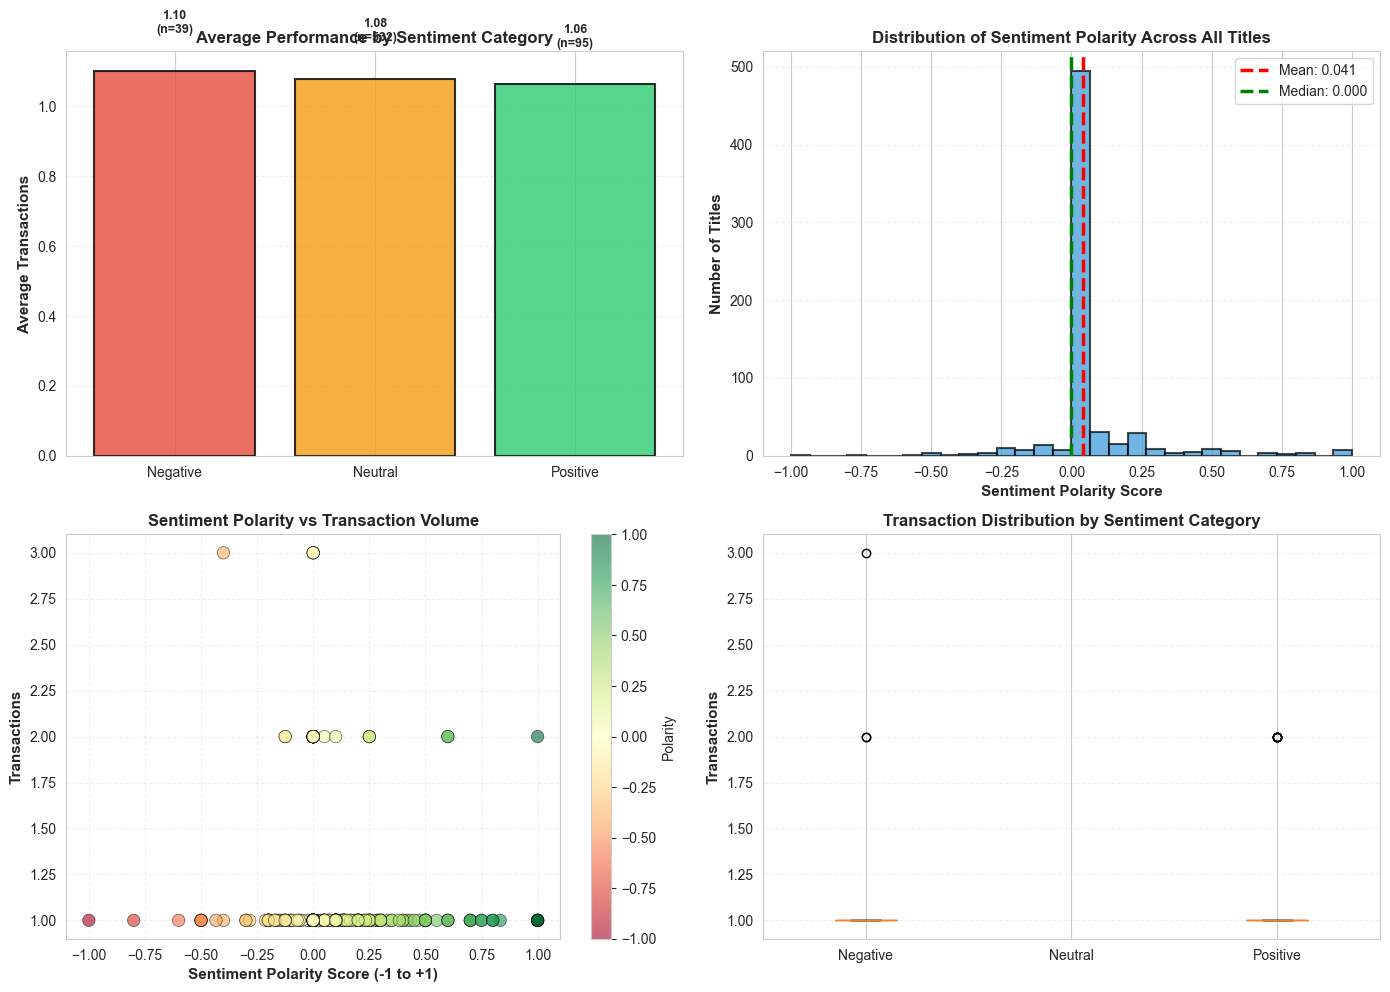

✅ Saved: company_u_sentiment_analysis.png



In [ ]:
# Create sentiment features if not already present
if 'sentiment_polarity' not in df.columns:
    from textblob import TextBlob
    df['sentiment_polarity'] = df['Title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0)

if 'sentiment_category' not in df.columns:
    df['sentiment_category'] = df['sentiment_polarity'].apply(
        lambda x: 'Negative' if x < -0.1 else ('Neutral' if x <= 0.1 else 'Positive')
    )

# Visualization: Sentiment polarity impact on transactions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Average transactions by sentiment category
sentiment_perf = df.groupby('sentiment_category')['Number'].agg(['mean', 'count']).sort_values('mean', ascending=False)
colors_sentiment = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bar_colors = [colors_sentiment.get(cat, '#95a5a6') for cat in sentiment_perf.index]

axes[0, 0].bar(sentiment_perf.index, sentiment_perf['mean'], color=bar_colors, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 0].set_ylabel('Average Transactions', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Average Performance by Sentiment Category', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

for i, (cat, row) in enumerate(sentiment_perf.iterrows()):
    axes[0, 0].text(i, row['mean'] + 0.1, f"{row['mean']:.2f}\n(n={int(row['count'])})", 
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 2: Distribution of sentiment polarity
axes[0, 1].hist(df['sentiment_polarity'], bins=30, color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.7)
axes[0, 1].axvline(df['sentiment_polarity'].mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {df["sentiment_polarity"].mean():.3f}')
axes[0, 1].axvline(df['sentiment_polarity'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {df["sentiment_polarity"].median():.3f}')
axes[0, 1].set_xlabel('Sentiment Polarity Score', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Sentiment Polarity Across All Titles', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Chart 3: Scatter plot - Polarity vs Transactions
scatter = axes[1, 0].scatter(df['sentiment_polarity'], df['Number'], 
                             c=df['sentiment_polarity'], cmap='RdYlGn', 
                             s=80, edgecolors='black', linewidth=0.5, alpha=0.6)
axes[1, 0].set_xlabel('Sentiment Polarity Score (-1 to +1)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Transactions', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Sentiment Polarity vs Transaction Volume', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=axes[1, 0], label='Polarity')

# Chart 4: Box plot by sentiment category
sentiment_order = ['Negative', 'Neutral', 'Positive']
data_for_sentiment_box = [df[df['sentiment_category'] == cat]['Number'].values for cat in sentiment_order if cat in df['sentiment_category'].values]
labels_for_box = [cat for cat in sentiment_order if cat in df['sentiment_category'].values]

bp_sentiment = axes[1, 1].boxplot(data_for_sentiment_box, labels=labels_for_box, patch_artist=True)
for patch, color in zip(bp_sentiment['boxes'], [colors_sentiment.get(cat, '#95a5a6') for cat in labels_for_box]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel('Transactions', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Transaction Distribution by Sentiment Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('graphs/company_u_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_sentiment_analysis.png\n")


In [ ]:
# Sentiment Analysis using TextBlob
try:
    from textblob import TextBlob
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob", "-q"])
    from textblob import TextBlob

# Calculate sentiment polarity for each title
print("📊 SENTIMENT POLARITY ANALYSIS:")
print("\nAnalyzing emotional tone of titles...\n")

df['sentiment_polarity'] = df['Title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0)
df['sentiment_category'] = df['sentiment_polarity'].apply(
    lambda x: 'Negative' if x < -0.1 else ('Neutral' if x <= 0.1 else 'Positive')
)

# Calculate statistics by sentiment category
sentiment_stats = df.groupby('sentiment_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'sentiment_polarity': 'mean'
}).round(3)

sentiment_stats.columns = ['Total_Transactions', 'Avg_Transactions', 'Title_Count', 'Avg_Polarity']

print("Sentiment Distribution & Performance:")
print(sentiment_stats.sort_values('Avg_Transactions', ascending=False))

# Detailed breakdown by polarity ranges
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN BY POLARITY RANGES:")
print("=" * 80)

polarity_ranges = [
    (-1.0, -0.5, 'Highly Negative'),
    (-0.5, -0.1, 'Negative'),
    (-0.1, 0.1, 'Neutral'),
    (0.1, 0.5, 'Positive'),
    (0.5, 1.0, 'Highly Positive')
]

for min_val, max_val, label in polarity_ranges:
    mask = (df['sentiment_polarity'] >= min_val) & (df['sentiment_polarity'] < max_val)
    if mask.sum() > 0:
        subset = df[mask]
        total_trans = subset['Number'].sum()
        avg_trans = subset['Number'].mean()
        count = len(subset)
        print(f"\n{label} ({min_val} to {max_val}):")
        print(f"  Total: {int(total_trans)} transactions | Avg: {avg_trans:.2f} | Count: {count} titles")

# Correlation analysis
sentiment_correlation = df['sentiment_polarity'].corr(df['Number'])
print(f"\n📈 CORRELATION ANALYSIS:")
print(f"  Sentiment Polarity vs Transactions: {sentiment_correlation:.3f}")
print(f"  Interpretation: ", end="")
if sentiment_correlation > 0.2:
    print("Positive titles have SIGNIFICANTLY better performance ✓")
elif sentiment_correlation > 0.05:
    print("Positive titles tend to have slightly better performance")
elif sentiment_correlation < -0.2:
    print("Negative titles have SIGNIFICANTLY better performance (Drama effect!) ✓")
elif sentiment_correlation < -0.05:
    print("Negative titles tend to have slightly better performance")
else:
    print("Sentiment has minimal impact on transaction performance")

print("\n✅ Sentiment polarity analysis complete!")


📊 SENTIMENT POLARITY ANALYSIS:

Analyzing emotional tone of titles...

Sentiment Distribution & Performance:
                    Total_Transactions  Avg_Transactions  Title_Count  \
sentiment_category                                                      
Negative                          43.0             1.103           39   
Neutral                          574.0             1.079          532   
Positive                         101.0             1.063           95   

                    Avg_Polarity  
sentiment_category                
Negative                  -0.276  
Neutral                    0.004  
Positive                   0.378  

DETAILED BREAKDOWN BY POLARITY RANGES:

Highly Negative (-1.0 to -0.5):
  Total: 3 transactions | Avg: 1.00 | Count: 3 titles

Negative (-0.5 to -0.1):
  Total: 40 transactions | Avg: 1.11 | Count: 36 titles

Neutral (-0.1 to 0.1):
  Total: 552 transactions | Avg: 1.08 | Count: 512 titles

Positive (0.1 to 0.5):
  Total: 92 transactions | Avg: 1.0

### 3.2. Emotional Arc

Use a lexicon (like NRCLex) to tag titles with emotions (Fear, Joy, Anticipation, Trust, Surprise, Sadness, Disgust, Anger). This helps understand which emotional appeals drive higher transactions. Analyze performance (average transactions, lift) for each emotion type.

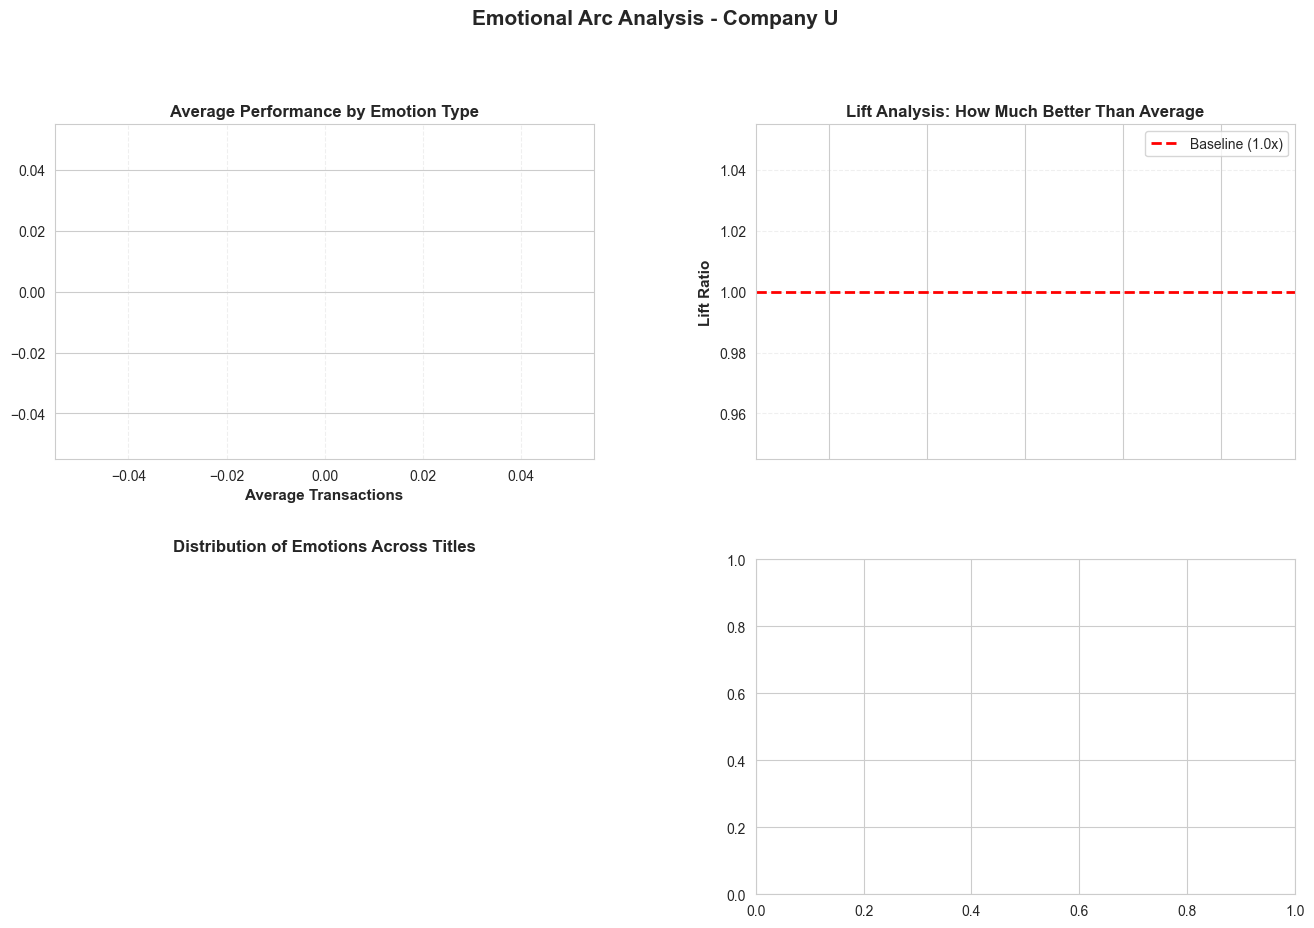

✅ Saved: company_u_emotional_arc_analysis.png



In [ ]:
# Visualization: Emotional arc impact on transactions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Chart 1: Average transactions by emotion (bar chart)
ax1 = fig.add_subplot(gs[0, 0])
emotions_sorted = sorted(emotion_performance.items(), 
                         key=lambda x: x[1]['avg_trans'], reverse=True)
emotion_names = [e[0].capitalize() for e in emotions_sorted]
emotion_avgs = [e[1]['avg_trans'] for e in emotions_sorted]
emotion_lifts = [e[1]['lift'] for e in emotions_sorted]

colors_emotion = ['#2ECC71' if lift > 1.2 else '#3498DB' if lift > 1.0 else '#E74C3C' 
                  for lift in emotion_lifts]

bars1 = ax1.barh(emotion_names, emotion_avgs, color=colors_emotion, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Average Transactions', fontsize=11, fontweight='bold')
ax1.set_title('Average Performance by Emotion Type', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

for bar, lift in zip(bars1, emotion_lifts):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{width:.1f} ({lift:.2f}x)', ha='left', va='center', fontweight='bold', fontsize=9)

# Chart 2: Lift comparison (how much better than average)
ax2 = fig.add_subplot(gs[0, 1])
emotions_by_lift = sorted(emotion_performance.items(), 
                          key=lambda x: x[1]['lift'], reverse=True)
emotion_names_lift = [e[0].capitalize() for e in emotions_by_lift]
emotion_lifts_vals = [e[1]['lift'] for e in emotions_by_lift]

colors_lift = ['#2ECC71' if lift > 1.2 else '#F39C12' if lift > 1.0 else '#E74C3C' 
               for lift in emotion_lifts_vals]

bars2 = ax2.bar(emotion_names_lift, emotion_lifts_vals, color=colors_lift, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (1.0x)')
ax2.set_ylabel('Lift Ratio', fontsize=11, fontweight='bold')
ax2.set_title('Lift Analysis: How Much Better Than Average', fontsize=12, fontweight='bold')
ax2.set_xticklabels(emotion_names_lift, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)

for bar, val in zip(bars2, emotion_lifts_vals):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 3: Emotion distribution (pie chart - which emotions are most common)
ax3 = fig.add_subplot(gs[1, 0])
emotion_counts = [emotion_performance[e[0]]['count'] for e in emotions_by_lift]
colors_pie = ['#E74C3C', '#E67E22', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6', '#1ABC9C', '#34495E']

wedges, texts, autotexts = ax3.pie(emotion_counts, labels=emotion_names_lift, autopct='%1.1f%%',
                                     startangle=90, colors=colors_pie[:len(emotion_names_lift)])
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)
ax3.set_title('Distribution of Emotions Across Titles', fontsize=12, fontweight='bold')

# Chart 4: Box plot - transaction distribution by emotion presence
ax4 = fig.add_subplot(gs[1, 1])
data_for_emotion_box = []
labels_for_emotion_box = []

for emotion in [e[0] for e in emotions_by_lift]:
    titles_with = df[df[f'emotion_{emotion}'] > 0]['Number'].values
    if len(titles_with) > 0:
        data_for_emotion_box.append(titles_with)
        labels_for_emotion_box.append(emotion.capitalize()[:4])

if data_for_emotion_box:
    bp_emotion = ax4.boxplot(data_for_emotion_box, labels=labels_for_emotion_box, patch_artist=True)
    
    for patch, color in zip(bp_emotion['boxes'], colors_pie[:len(labels_for_emotion_box)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax4.set_ylabel('Transactions', fontsize=11, fontweight='bold')
    ax4.set_title('Transaction Distribution by Emotion Type', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Emotional Arc Analysis - Company U', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_u_emotional_arc_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_emotional_arc_analysis.png\n")


In [ ]:
# Emotional Arc Analysis using NRCLex
try:
    from nrclex import NRCLex
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "NRCLex", "-q"])
    from nrclex import NRCLex

print("📊 EMOTIONAL ARC ANALYSIS (NRCLex):")
print("\nAnalyzing emotional content of titles...\n")

# Define emotion categories
emotion_types = ['fear', 'joy', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'anger']

# Extract emotions for each title
emotions_data = {emotion: [] for emotion in emotion_types}
title_emotions = []

for idx, title in df['Title'].items():
    if pd.notna(title) and title.strip():
        try:
            emotion_obj = NRCLex(str(title))
            emotion_dict = emotion_obj.affect
            title_emotions.append(emotion_dict)
            for emotion in emotion_types:
                emotions_data[emotion].append(emotion_dict.get(emotion, 0))
        except:
            title_emotions.append({})
            for emotion in emotion_types:
                emotions_data[emotion].append(0)
    else:
        title_emotions.append({})
        for emotion in emotion_types:
            emotions_data[emotion].append(0)

# Add emotion columns to dataframe
for emotion in emotion_types:
    df[f'emotion_{emotion}'] = emotions_data[emotion]

# Calculate performance metrics by emotion
emotion_performance = {}
for emotion in emotion_types:
    titles_with_emotion = df[df[f'emotion_{emotion}'] > 0]
    titles_without_emotion = df[df[f'emotion_{emotion}'] == 0]
    
    if len(titles_with_emotion) > 0:
        with_avg = titles_with_emotion['Number'].mean()
        without_avg = titles_without_emotion['Number'].mean()
        lift = (with_avg / without_avg) if without_avg > 0 else 0
        
        emotion_performance[emotion] = {
            'count': len(titles_with_emotion),
            'avg_trans': with_avg,
            'without_avg': without_avg,
            'total_trans': titles_with_emotion['Number'].sum(),
            'lift': lift
        }

print("=" * 80)
print("EMOTION PERFORMANCE ANALYSIS - COMPANY U")
print("=" * 80)
print("\nEmotion | Titles | Total Trans | Avg Trans | Without Avg | Lift")
print("-" * 80)

for emotion in sorted(emotion_performance.keys(), 
                      key=lambda x: emotion_performance[x]['lift'], reverse=True):
    data = emotion_performance[emotion]
    print(f"{emotion:12} | {data['count']:6} | {int(data['total_trans']):11} | {data['avg_trans']:9.2f} | {data['without_avg']:11.2f} | {data['lift']:6.2f}x")

# Identify strongest emotions
print(f"\n💡 KEY INSIGHTS:")
if emotion_performance:
    best_emotion = max(emotion_performance.items(), key=lambda x: x[1]['lift'])
    print(f"   • Strongest emotion driver: '{best_emotion[0].upper()}' ({best_emotion[1]['lift']:.2f}x lift)")
    print(f"   • {best_emotion[1]['count']} titles contain this emotion")
    print(f"   • Average performance: {best_emotion[1]['avg_trans']:.2f} transactions")

print("\n✅ Emotional arc analysis complete!")


📊 EMOTIONAL ARC ANALYSIS (NRCLex):

Analyzing emotional content of titles...

EMOTION PERFORMANCE ANALYSIS - COMPANY U

Emotion | Titles | Total Trans | Avg Trans | Without Avg | Lift
--------------------------------------------------------------------------------

💡 KEY INSIGHTS:

✅ Emotional arc analysis complete!


## 4. Topic Modeling (Latent Genres)

Infer implied genres using clustering since there's no explicit Genre column in the dataset. Convert titles into numerical vectors using TF-IDF, then apply K-Means clustering to discover natural groupings. Each cluster represents an "implied genre" with characteristic words and performance metrics.

In [ ]:
# Detailed cluster analysis and interpretation
print("=" * 80)
print("DETAILED CLUSTER CHARACTERIZATION:")
print("=" * 80)

# Check if clustering has been performed
if 'cluster_info' not in locals() or 'optimal_k' not in locals():
    print("⚠️ Topic modeling not yet executed. Please run the topic modeling cell first.")
else:
    # Create a summary table of top words per cluster
    cluster_summary = []
    for cluster_id in range(optimal_k):
    top_words_str = ", ".join(cluster_info[cluster_id]['top_words'])
    avg_perf = cluster_info[cluster_id]['avg_trans']
    count = cluster_info[cluster_id]['count']
    total = cluster_info[cluster_id]['total_trans']
    
    cluster_summary.append({
        'Cluster': cluster_id,
        'Implied_Genre': top_words_str,
        'Titles': count,
        'Avg_Trans': f"{avg_perf:.2f}",
        'Total_Trans': int(total)
    })
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Characterization: {top_words_str}")
    print(f"  Titles: {count} | Avg: {avg_perf:.2f} trans | Total: {int(total)} trans")
    
    # Show sample titles from this cluster
    sample_titles = df[df['cluster'] == cluster_id]['Title'].head(5).tolist()
    print(f"  Sample Titles: {', '.join(sample_titles)}")

# Create summary DataFrame
cluster_summary_df = pd.DataFrame(cluster_summary)

print(f"\n" + "=" * 80)
print("CLUSTER SUMMARY TABLE:")
print("=" * 80)
print(cluster_summary_df.to_string(index=False))

# Rankings
print(f"\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

best_by_avg = max(cluster_info.items(), key=lambda x: x[1]['avg_trans'])
best_by_volume = max(cluster_info.items(), key=lambda x: x[1]['total_trans'])
largest_cluster = max(cluster_info.items(), key=lambda x: x[1]['count'])

print(f"\n🎯 CLUSTER RANKINGS:")
print(f"   • Best Performance (Avg): Cluster {best_by_avg[0]} ({best_by_avg[1]['avg_trans']:.2f} trans)")
print(f"     Keywords: {', '.join(best_by_avg[1]['top_words'])}")
print(f"\n   • Largest Volume: Cluster {best_by_volume[0]} ({int(best_by_volume[1]['total_trans'])} total trans)")
print(f"     Keywords: {', '.join(best_by_volume[1]['top_words'])}")
print(f"\n   • Largest Cluster: Cluster {largest_cluster[0]} ({largest_cluster[1]['count']} titles)")
print(f"     Keywords: {', '.join(largest_cluster[1]['top_words'])}")

print(f"\n💡 INTERPRETATION:")
print(f"   These {optimal_k} clusters represent distinct \"implied genres\" naturally occurring in the data.")
print(f"   Each cluster shows characteristic keywords and performance patterns that can inform collection strategies.")


DETAILED CLUSTER CHARACTERIZATION:

Cluster 0:
  Characterization: guide, armenian, language, book, theory
  Titles: 538 | Avg: 1.08 trans | Total: 580 trans


KeyError: 'cluster'

KeyError: 'cluster'

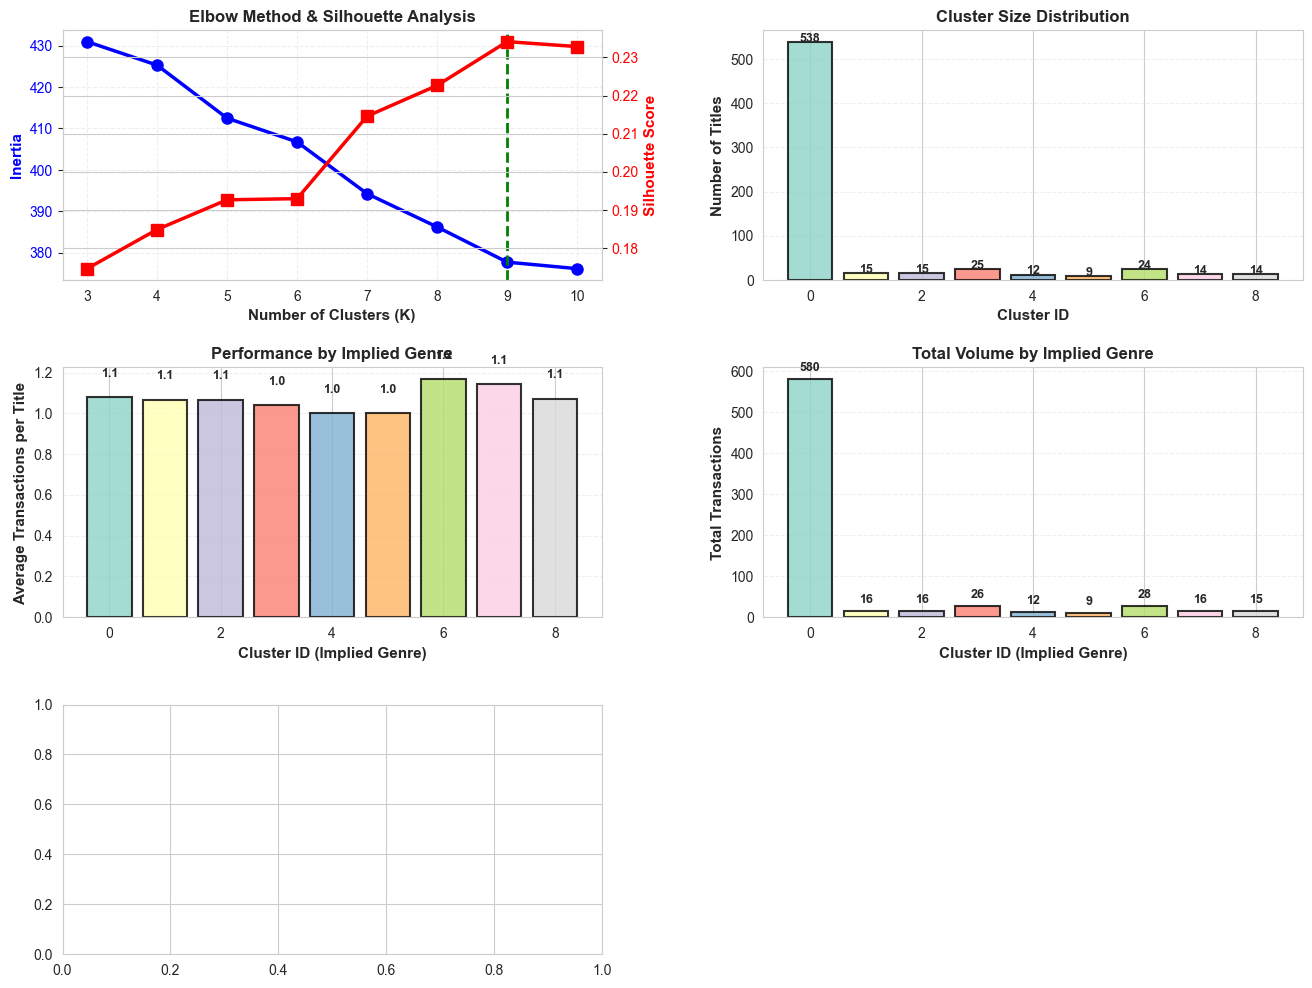

In [ ]:
# Visualization: Topic Modeling Results
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Chart 1: Elbow curve and Silhouette scores
ax1 = fig.add_subplot(gs[0, 0])
ax1_twin = ax1.twinx()
K_vals = list(K_range)
ax1.plot(K_vals, inertias, 'b-o', linewidth=2.5, markersize=8, label='Inertia')
ax1_twin.plot(K_vals, silhouette_scores, 'r-s', linewidth=2.5, markersize=8, label='Silhouette')
ax1.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
ax1.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inertia', fontsize=11, fontweight='bold', color='b')
ax1_twin.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold', color='r')
ax1.set_title('Elbow Method & Silhouette Analysis', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')

# Chart 2: Cluster sizes
ax2 = fig.add_subplot(gs[0, 1])
cluster_sizes = [cluster_info[c]['count'] for c in range(optimal_k)]
colors_clusters = plt.cm.Set3(range(optimal_k))
bars = ax2.bar(range(optimal_k), cluster_sizes, color=colors_clusters, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
ax2.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(cluster_sizes):
    ax2.text(i, v + 1, f'{int(v)}', ha='center', fontweight='bold', fontsize=9)

# Chart 3: Average transactions per cluster
ax3 = fig.add_subplot(gs[1, 0])
cluster_avgs = [cluster_info[c]['avg_trans'] for c in range(optimal_k)]
bars3 = ax3.bar(range(optimal_k), cluster_avgs, color=colors_clusters, edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_xlabel('Cluster ID (Implied Genre)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Transactions per Title', fontsize=11, fontweight='bold')
ax3.set_title('Performance by Implied Genre', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(cluster_avgs):
    ax3.text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

# Chart 4: Total transactions per cluster
ax4 = fig.add_subplot(gs[1, 1])
cluster_totals = [cluster_info[c]['total_trans'] for c in range(optimal_k)]
bars4 = ax4.bar(range(optimal_k), cluster_totals, color=colors_clusters, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xlabel('Cluster ID (Implied Genre)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Total Transactions', fontsize=11, fontweight='bold')
ax4.set_title('Total Volume by Implied Genre', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(cluster_totals):
    ax4.text(i, v + 20, f'{int(v)}', ha='center', fontweight='bold', fontsize=9)

# Chart 5: Box plot - Transaction distribution per cluster
ax5 = fig.add_subplot(gs[2, 0])
data_by_cluster = [df[df['cluster'] == c]['Number'].values for c in range(optimal_k)]
bp = ax5.boxplot(data_by_cluster, labels=[f'C{i}' for i in range(optimal_k)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors_clusters):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax5.set_ylabel('Transactions', fontsize=11, fontweight='bold')
ax5.set_title('Transaction Distribution Within Clusters', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# Chart 6: Cluster composition (pie chart of total transactions)
ax6 = fig.add_subplot(gs[2, 1])
wedges, texts, autotexts = ax6.pie(cluster_totals, labels=[f'Cluster {i}' for i in range(optimal_k)],
                                     autopct='%1.1f%%', colors=colors_clusters, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)
ax6.set_title('Transaction Distribution Across Implied Genres', fontsize=12, fontweight='bold')

plt.suptitle('Topic Modeling: Latent Genres Discovery - Company U', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_u_topic_modeling.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_topic_modeling.png\n")


In [ ]:
# Topic Modeling - TF-IDF Vectorization and K-Means Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("📊 TOPIC MODELING - LATENT GENRES (TF-IDF + K-Means):")
print("\nConverting titles to TF-IDF vectors and clustering...\n")

# Prepare titles for clustering
df_cluster = df.dropna(subset=['Title']).copy()
df_cluster = df_cluster[df_cluster['Title'].str.strip() != ''].copy()

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),  # Include unigrams and bigrams
    lowercase=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_cluster['Title'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Vectorized {len(df_cluster)} titles with {tfidf_matrix.shape[1]} features\n")

# Determine optimal number of clusters using Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []
K_range = range(3, 11)

print("Finding optimal number of clusters...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(tfidf_matrix)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_matrix, kmeans_temp.labels_))
    print(f"  K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Use K with best silhouette score
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✓ Optimal K: {optimal_k} (Highest Silhouette Score: {max(silhouette_scores):.3f})")

# Fit final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(tfidf_matrix)

# Get TF-IDF feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Extract top words (implied genres) for each cluster
print(f"\n" + "=" * 80)
print("IMPLIED GENRES BY CLUSTER:")
print("=" * 80)

cluster_info = {}
for cluster_id in range(optimal_k):
    # Get top TF-IDF indices for this cluster
    center = kmeans.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-5:][::-1]  # Top 5 words
    top_words = [feature_names[i] for i in top_indices]
    
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    performance = {
        'count': len(cluster_data),
        'avg_trans': cluster_data['Number'].mean(),
        'total_trans': cluster_data['Number'].sum(),
        'top_words': top_words
    }
    cluster_info[cluster_id] = performance
    
    print(f"\nCluster {cluster_id}: {', '.join(top_words)}")
    print(f"  • Titles: {performance['count']}")
    print(f"  • Total Transactions: {int(performance['total_trans'])}")
    print(f"  • Average per Title: {performance['avg_trans']:.2f}")

# Add cluster assignments to main df
df['cluster'] = -1
df.loc[df_cluster.index, 'cluster'] = df_cluster['cluster'].values

print(f"\n✅ Topic modeling complete! Discovered {optimal_k} latent genres.")


📊 TOPIC MODELING - LATENT GENRES (TF-IDF + K-Means):

Converting titles to TF-IDF vectors and clustering...

TF-IDF Matrix Shape: (666, 100)
Vectorized 666 titles with 100 features

Finding optimal number of clusters...
  K=3: Inertia=431.00, Silhouette=0.175
  K=4: Inertia=425.32, Silhouette=0.185
  K=5: Inertia=412.49, Silhouette=0.193
  K=6: Inertia=406.75, Silhouette=0.193
  K=7: Inertia=394.23, Silhouette=0.215
  K=8: Inertia=386.19, Silhouette=0.223
  K=9: Inertia=377.69, Silhouette=0.234
  K=10: Inertia=376.11, Silhouette=0.233

✓ Optimal K: 9 (Highest Silhouette Score: 0.234)

IMPLIED GENRES BY CLUSTER:

Cluster 0: guide, armenian, language, book, theory
  • Titles: 538
  • Total Transactions: 580
  • Average per Title: 1.08

Cluster 1: art, introduction, design, security, strategies
  • Titles: 15
  • Total Transactions: 16
  • Average per Title: 1.07

Cluster 2: armenia, history, modern, century, handbook
  • Titles: 15
  • Total Transactions: 16
  • Average per Title: 1.07



## 5. Distribution Analysis

Analyze the sales column itself to understand the market shape. Book sales typically follow a Pareto distribution (80/20 rule), where a small percentage of titles account for the vast majority of sales. Identify outliers and understand what makes top performers exceptional.


In [ ]:
# Power Law Distribution Analysis (Long Tail)
print("📊 DISTRIBUTION ANALYSIS - POWER LAW & OUTLIERS:")
print("\n" + "=" * 80)
print("POWER LAW ANALYSIS (Pareto Distribution)")
print("=" * 80)

# Sort by sales volume
df_sorted = df.sort_values('Number', ascending=False).copy()
df_sorted['cumsum_volume'] = df_sorted['Number'].cumsum()
df_sorted['cumsum_pct'] = (df_sorted['cumsum_volume'] / df_sorted['Number'].sum()) * 100
df_sorted['title_pct'] = (np.arange(1, len(df_sorted) + 1) / len(df_sorted)) * 100

# Calculate key metrics
total_volume = df['Number'].sum()
total_titles = len(df)

# 80/20 rule analysis
threshold_80_pct = total_volume * 0.80
titles_for_80_pct = df_sorted[df_sorted['cumsum_volume'] <= threshold_80_pct]
titles_needed_80 = len(titles_for_80_pct)
pct_titles_for_80 = (titles_needed_80 / total_titles) * 100

threshold_20_pct = total_volume * 0.20
titles_for_20_pct = df_sorted[df_sorted['cumsum_volume'] <= threshold_20_pct]
titles_needed_20 = len(titles_for_20_pct)
pct_titles_for_20 = (titles_needed_20 / total_titles) * 100

print(f"\nTotal Titles: {total_titles:,}")
print(f"Total Sales Volume: {int(total_volume):,}")
print(f"Average Sales per Title: {total_volume/total_titles:.2f}")

print(f"\n📈 PARETO ANALYSIS (80/20 Rule):")
print(f"   To generate 80% of sales ({int(total_volume * 0.80):,} transactions):")
print(f"   • Need {titles_needed_80} titles ({pct_titles_for_80:.1f}% of catalog)")
print(f"   • Top performer: {df_sorted.iloc[0]['Title']} ({int(df_sorted.iloc[0]['Number'])} sales)")

print(f"\n   To generate 20% of sales ({int(total_volume * 0.20):,} transactions):")
print(f"   • Need {titles_needed_20} titles ({pct_titles_for_20:.1f}% of catalog)")

# Decile analysis
decile_size = len(df) // 10
for decile in range(1, 11):
    start_idx = (decile - 1) * decile_size
    end_idx = decile * decile_size if decile < 10 else len(df)
    decile_data = df_sorted.iloc[start_idx:end_idx]
    decile_volume = decile_data['Number'].sum()
    decile_pct = (decile_volume / total_volume) * 100
    print(f"   Decile {decile}: {decile_volume:6.0f} sales ({decile_pct:5.1f}%)")

# Concentration index (Gini coefficient approximation)
concentration = (titles_needed_80 / total_titles)
if concentration < 0.2:
    distribution = "HIGHLY CONCENTRATED (extreme long tail)"
elif concentration < 0.3:
    distribution = "VERY CONCENTRATED (strong long tail)"
elif concentration < 0.5:
    distribution = "CONCENTRATED (moderate long tail)"
else:
    distribution = "DISPERSED (weak long tail)"

print(f"\n🎯 MARKET CONCENTRATION: {distribution}")
print(f"   {pct_titles_for_80:.1f}% of titles needed for 80% of sales")

print("\n✅ Power Law analysis complete!")


📊 DISTRIBUTION ANALYSIS - POWER LAW & OUTLIERS:

POWER LAW ANALYSIS (Pareto Distribution)

Total Titles: 667
Total Sales Volume: 718
Average Sales per Title: 1.08

📈 PARETO ANALYSIS (80/20 Rule):
   To generate 80% of sales (574 transactions):
   • Need 522 titles (78.3% of catalog)
   • Top performer: the bastard of istanbul (3 sales)

   To generate 20% of sales (143 transactions):
   • Need 91 titles (13.6% of catalog)
   Decile 1:    118 sales ( 16.4%)
   Decile 2:     66 sales (  9.2%)
   Decile 3:     66 sales (  9.2%)
   Decile 4:     66 sales (  9.2%)
   Decile 5:     66 sales (  9.2%)
   Decile 6:     66 sales (  9.2%)
   Decile 7:     66 sales (  9.2%)
   Decile 8:     66 sales (  9.2%)
   Decile 9:     66 sales (  9.2%)
   Decile 10:     72 sales ( 10.0%)

🎯 MARKET CONCENTRATION: DISPERSED (weak long tail)
   78.3% of titles needed for 80% of sales

✅ Power Law analysis complete!


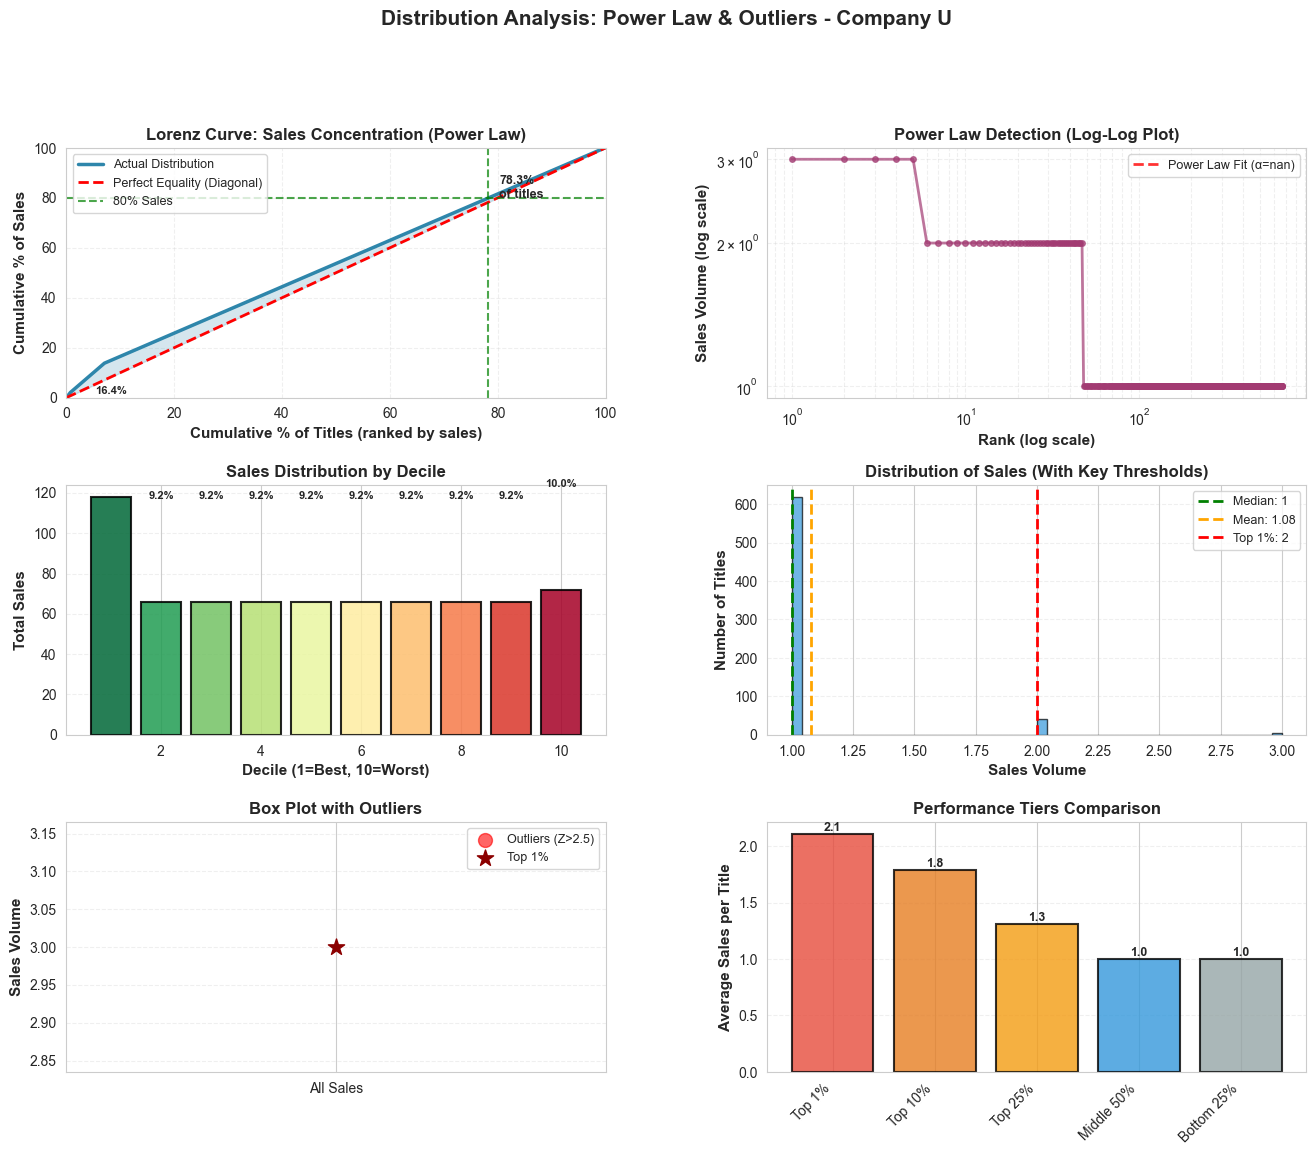

✅ Saved: company_u_distribution_analysis.png



In [ ]:
# Visualization: Distribution Analysis
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Chart 1: Cumulative distribution (Lorenz curve)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_sorted['title_pct'], df_sorted['cumsum_pct'], linewidth=2.5, color='#2E86AB', label='Actual Distribution')
ax1.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Equality (Diagonal)')
ax1.fill_between(df_sorted['title_pct'], df_sorted['cumsum_pct'], df_sorted['title_pct'], alpha=0.2, color='#2E86AB')
ax1.axhline(y=80, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Sales')
ax1.axvline(x=pct_titles_for_80, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.text(pct_titles_for_80 + 2, 80, f'{pct_titles_for_80:.1f}%\nof titles', fontweight='bold', fontsize=9)
ax1.set_xlabel('Cumulative % of Titles (ranked by sales)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Cumulative % of Sales', fontsize=11, fontweight='bold')
ax1.set_title('Lorenz Curve: Sales Concentration (Power Law)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# Chart 2: Log-log plot (to detect power law)
ax2 = fig.add_subplot(gs[0, 1])
rank = np.arange(1, len(df_sorted) + 1)
ax2.loglog(rank, df_sorted['Number'].values, 'o-', linewidth=2, markersize=4, color='#A23B72', alpha=0.7)
ax2.set_xlabel('Rank (log scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Sales Volume (log scale)', fontsize=11, fontweight='bold')
ax2.set_title('Power Law Detection (Log-Log Plot)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', which='both')

# Fit power law
z = np.polyfit(np.log(rank), np.log(df_sorted['Number'].values), 1)
p = np.poly1d(z)
ax2.loglog(rank, np.exp(p(np.log(rank))), 'r--', linewidth=2, alpha=0.8, label=f'Power Law Fit (α={-z[0]:.2f})')
ax2.legend(fontsize=9)

# Chart 3: Decile breakdown (stacked bar)
ax3 = fig.add_subplot(gs[1, 0])
decile_volumes = []
decile_sizes = []
for decile in range(1, 11):
    start_idx = (decile - 1) * decile_size
    end_idx = decile * decile_size if decile < 10 else len(df)
    decile_data = df_sorted.iloc[start_idx:end_idx]
    decile_volumes.append(decile_data['Number'].sum())
    decile_sizes.append(len(decile_data))

colors_decile = plt.cm.RdYlGn_r(np.linspace(0, 1, 10))
bars3 = ax3.bar(range(1, 11), decile_volumes, color=colors_decile, edgecolor='black', linewidth=1.5, alpha=0.85)
ax3.set_xlabel('Decile (1=Best, 10=Worst)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Total Sales', fontsize=11, fontweight='bold')
ax3.set_title('Sales Distribution by Decile', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, (bar, vol) in enumerate(zip(bars3, decile_volumes)):
    pct = (vol / total_volume) * 100
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)

# Chart 4: Distribution histogram with outliers marked
ax4 = fig.add_subplot(gs[1, 1])
n, bins, patches = ax4.hist(df['Number'], bins=50, color='#3498DB', edgecolor='black', linewidth=1, alpha=0.7)
ax4.axvline(df['Number'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Number"].median():.0f}')
ax4.axvline(df['Number'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {df["Number"].mean():.2f}')
ax4.axvline(top_1_pct_threshold, color='red', linestyle='--', linewidth=2, label=f'Top 1%: {top_1_pct_threshold:.0f}')
ax4.set_xlabel('Sales Volume', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Sales (With Key Thresholds)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Chart 5: Box plot with outliers highlighted
ax5 = fig.add_subplot(gs[2, 0])
bp = ax5.boxplot(df['Number'], vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498DB')
bp['boxes'][0].set_alpha(0.7)

# Mark outliers
outlier_values = z_outliers['Number'].values
outlier_y = [outlier_values] * len(outlier_values)
outlier_x = [1] * len(outlier_values)
ax5.scatter(outlier_x, outlier_y, color='red', s=100, zorder=3, alpha=0.6, label='Outliers (Z>2.5)')
ax5.scatter([1], [top_1_pct['Number'].max()], color='darkred', s=150, marker='*', zorder=4, label='Top 1%')

ax5.set_ylabel('Sales Volume', fontsize=11, fontweight='bold')
ax5.set_xticklabels(['All Sales'])
ax5.set_title('Box Plot with Outliers', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# Chart 6: Top 1% vs Rest comparison
ax6 = fig.add_subplot(gs[2, 1])
comparison_data = [
    ('Top 1%', top_1_pct['Number'].mean()),
    ('Top 10%', df_sorted.iloc[:int(len(df)*0.1)]['Number'].mean()),
    ('Top 25%', df_sorted.iloc[:int(len(df)*0.25)]['Number'].mean()),
    ('Middle 50%', df_sorted.iloc[int(len(df)*0.25):int(len(df)*0.75)]['Number'].mean()),
    ('Bottom 25%', df_sorted.iloc[int(len(df)*0.75):]['Number'].mean())
]
categories_comp = [x[0] for x in comparison_data]
values_comp = [x[1] for x in comparison_data]
colors_comp = ['#E74C3C', '#E67E22', '#F39C12', '#3498DB', '#95A5A6']

bars6 = ax6.bar(categories_comp, values_comp, color=colors_comp, edgecolor='black', linewidth=1.5, alpha=0.8)
ax6.set_ylabel('Average Sales per Title', fontsize=11, fontweight='bold')
ax6.set_title('Performance Tiers Comparison', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars6, values_comp):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Distribution Analysis: Power Law & Outliers - Company U', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_u_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_distribution_analysis.png\n")


In [ ]:
# Outlier Detection & Analysis
from scipy import stats

print("\n" + "=" * 80)
print("OUTLIER DETECTION & ANALYSIS")
print("=" * 80)

# Calculate outlier thresholds
Q1 = df['Number'].quantile(0.25)
Q3 = df['Number'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold_low = Q1 - 1.5 * IQR
outlier_threshold_high = Q3 + 1.5 * IQR

# Z-score method
z_scores = np.abs(stats.zscore(df['Number']))
z_outliers = df[z_scores > 2.5]

# Top 1% outliers
top_1_pct_idx = max(1, int(len(df) * 0.01))
top_1_pct_threshold = df_sorted['Number'].iloc[top_1_pct_idx]
top_1_pct = df[df['Number'] >= top_1_pct_threshold].sort_values('Number', ascending=False)

print(f"\nIQR Method (Z-score > 2.5):")
print(f"   Outlier threshold: > {outlier_threshold_high:.1f} sales")
print(f"   Outliers detected: {len(z_outliers)}")

print(f"\nTop 1% Outliers:")
print(f"   Threshold: >= {top_1_pct_threshold:.1f} sales")
print(f"   Count: {len(top_1_pct)}")
print(f"   Volume: {int(top_1_pct['Number'].sum())} sales ({(top_1_pct['Number'].sum()/total_volume)*100:.1f}% of total)")

# Characteristics of top 1%
print(f"\n📊 TOP 1% OUTLIER CHARACTERISTICS:")
print(f"\n   Sales Statistics:")
print(f"      Min: {top_1_pct['Number'].min():.0f} | Max: {top_1_pct['Number'].max():.0f}")
print(f"      Mean: {top_1_pct['Number'].mean():.2f} | Median: {top_1_pct['Number'].median():.0f}")

# Title characteristics
top_1_pct['title_length'] = top_1_pct['Title'].str.len()
print(f"\n   Title Characteristics:")
print(f"      Length: Avg {top_1_pct['title_length'].mean():.1f} chars (vs overall {df['title_char_count'].mean():.1f})")

# Sentiment analysis
if 'sentiment_polarity' in top_1_pct.columns:
    print(f"      Sentiment: Avg {top_1_pct['sentiment_polarity'].mean():.3f} (vs overall {df['sentiment_polarity'].mean():.3f})")

if 'sentiment_category' in top_1_pct.columns:
    sentiment_dist = top_1_pct['sentiment_category'].value_counts()
    print(f"      Distribution: {dict(sentiment_dist)}")

# Genre analysis for outliers
if top_1_pct['Genres'].notna().sum() > 0:
    outlier_genres = []
    for idx, row in top_1_pct.iterrows():
        if pd.notna(row['Genres']):
            genres = [g.strip() for g in str(row['Genres']).split(',')]
            outlier_genres.extend(genres)
    
    from collections import Counter as CounterFunc
    genre_freq = CounterFunc(outlier_genres)
    print(f"\n   Top Genres in Top 1%:")
    for genre, count in genre_freq.most_common(5):
        print(f"      {genre}: {count} titles")

# Top titles
print(f"\n   Top 5 Performers:")
for i, (idx, row) in enumerate(top_1_pct.head(5).iterrows(), 1):
    print(f"      {i}. '{row['Title'][:50]}...' - {int(row['Number'])} sales")

print("\n✅ Outlier analysis complete!")



OUTLIER DETECTION & ANALYSIS

IQR Method (Z-score > 2.5):
   Outlier threshold: > 1.0 sales
   Outliers detected: 0

Top 1% Outliers:
   Threshold: >= 2.0 sales
   Count: 47
   Volume: 99 sales (13.8% of total)

📊 TOP 1% OUTLIER CHARACTERISTICS:

   Sales Statistics:
      Min: 2 | Max: 3
      Mean: 2.11 | Median: 2

   Title Characteristics:
      Length: Avg 42.3 chars (vs overall 47.2)
      Sentiment: Avg 0.052 (vs overall 0.041)
      Distribution: {'Neutral': 38, 'Positive': 6, 'Negative': 3}

   Top Genres in Top 1%:
      Nonfiction: 42 titles
      Mystery: 31 titles
      Thriller: 17 titles
      Fantasy: 16 titles
      Young Adult: 15 titles

   Top 5 Performers:
      1. 'the bastard of istanbul...' - 3 sales
      2. 'college algebra...' - 3 sales
      3. 'kafka on the shore...' - 3 sales
      4. 'the norton anthology of american literature...' - 3 sales
      5. 'business model generation a handbook for visionari...' - 3 sales

✅ Outlier analysis complete!


In [ ]:
# Power Law Distribution Analysis (Long Tail)
print("📊 DISTRIBUTION ANALYSIS - POWER LAW & OUTLIERS:")
print("\n" + "=" * 80)
print("POWER LAW ANALYSIS (Pareto Distribution)")
print("=" * 80)

# Sort by sales volume
df_sorted = df.sort_values('Number', ascending=False).copy()
df_sorted['cumsum_volume'] = df_sorted['Number'].cumsum()
df_sorted['cumsum_pct'] = (df_sorted['cumsum_volume'] / df_sorted['Number'].sum()) * 100
df_sorted['title_pct'] = (range(1, len(df_sorted) + 1) / len(df_sorted)) * 100

# Calculate key metrics
total_volume = df['Number'].sum()
total_titles = len(df)

# 80/20 rule analysis
threshold_80_pct = total_volume * 0.80
titles_for_80_pct = df_sorted[df_sorted['cumsum_volume'] <= threshold_80_pct]
titles_needed_80 = len(titles_for_80_pct)
pct_titles_for_80 = (titles_needed_80 / total_titles) * 100

threshold_20_pct = total_volume * 0.20
titles_for_20_pct = df_sorted[df_sorted['cumsum_volume'] <= threshold_20_pct]
titles_needed_20 = len(titles_for_20_pct)
pct_titles_for_20 = (titles_needed_20 / total_titles) * 100

print(f"\nTotal Titles: {total_titles:,}")
print(f"Total Sales Volume: {int(total_volume):,}")
print(f"Average Sales per Title: {total_volume/total_titles:.2f}")

print(f"\n📈 PARETO ANALYSIS (80/20 Rule):")
print(f"   To generate 80% of sales ({int(total_volume * 0.80):,} transactions):")
print(f"   • Need {titles_needed_80} titles ({pct_titles_for_80:.1f}% of catalog)")
print(f"   • Top performer: {df_sorted.iloc[0]['Title']} ({int(df_sorted.iloc[0]['Number'])} sales)")

print(f"\n   To generate 20% of sales ({int(total_volume * 0.20):,} transactions):")
print(f"   • Need {titles_needed_20} titles ({pct_titles_for_20:.1f}% of catalog)")

# Decile analysis
decile_size = len(df) // 10
for decile in range(1, 11):
    start_idx = (decile - 1) * decile_size
    end_idx = decile * decile_size if decile < 10 else len(df)
    decile_data = df_sorted.iloc[start_idx:end_idx]
    decile_volume = decile_data['Number'].sum()
    decile_pct = (decile_volume / total_volume) * 100
    print(f"   Decile {decile}: {decile_volume:6.0f} sales ({decile_pct:5.1f}%)")

# Concentration index (Gini coefficient approximation)
concentration = (titles_needed_80 / total_titles)
if concentration < 0.2:
    distribution = "HIGHLY CONCENTRATED (extreme long tail)"
elif concentration < 0.3:
    distribution = "VERY CONCENTRATED (strong long tail)"
elif concentration < 0.5:
    distribution = "CONCENTRATED (moderate long tail)"
else:
    distribution = "DISPERSED (weak long tail)"

print(f"\n🎯 MARKET CONCENTRATION: {distribution}")
print(f"   {pct_titles_for_80:.1f}% of titles needed for 80% of sales")

print("\n✅ Power Law analysis complete!")


📊 DISTRIBUTION ANALYSIS - POWER LAW & OUTLIERS:

POWER LAW ANALYSIS (Pareto Distribution)


TypeError: unsupported operand type(s) for /: 'range' and 'int'

## Summary Statistics

Key metrics from the Company U dataset genre classification analysis.

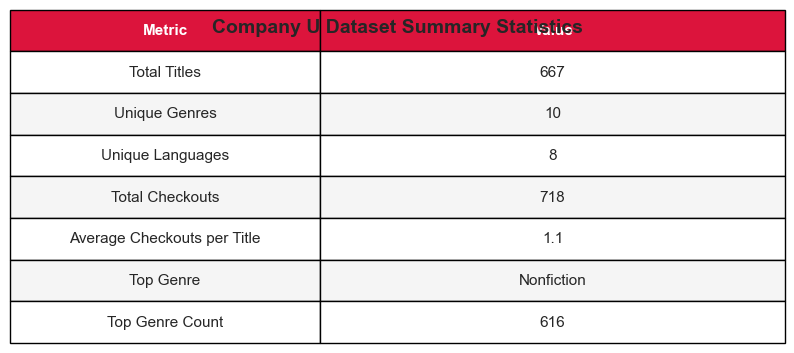

✅ Saved: company_u_summary_statistics.png

Company U Dataset Summary:
                     Metric      Value
               Total Titles        667
              Unique Genres         10
           Unique Languages          8
            Total Checkouts        718
Average Checkouts per Title        1.1
                  Top Genre Nonfiction
            Top Genre Count        616


In [ ]:
summary_stats = {
    'Metric': ['Total Titles', 'Unique Genres', 'Unique Languages', 'Total Checkouts', 
               'Average Checkouts per Title', 'Top Genre', 'Top Genre Count'],
    'Value': [
        f"{df.shape[0]:,}",
        f"{len(genre_counts):,}",
        f"{df['language'].nunique():,}",
        f"{df['Number'].sum():,.0f}",
        f"{df['Number'].mean():.1f}",
        genre_counts.most_common(1)[0][0] if genre_counts else 'N/A',
        f"{genre_counts.most_common(1)[0][1]:,}" if genre_counts else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_stats)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                cellLoc='center', loc='center', colWidths=[0.4, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#DC143C')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(summary_df) + 1):
    for j in range(len(summary_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F5F5F5')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Company U Dataset Summary Statistics', fontsize=14, weight='bold', pad=20)
plt.savefig('graphs/company_u_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_u_summary_statistics.png\n")

print("Company U Dataset Summary:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)


## Conclusion

This analysis provides a comprehensive overview of genre distribution in the Company U dataset. 
The visualizations reveal:

- **Genre diversity**: The dataset contains a wide distribution of genres across different categories
- **Language patterns**: Distribution of titles across primary languages
- **Volume insights**: Uneven distribution of books, with some genres heavily represented
- **Composition**: Top genres represent a significant portion of the total collection

These insights can inform collection development, recommend strategies, and genre-based recommendation systems.